# Newscast Speech - Exploratory Data Analysis

Processing Big Data, Task 1 (EDA & Visualization). Group 20.

This notebook explores the speech transcripts and EuroLLM embeddings from the RTP and TVI evening newscasts.
Cells run top to bottom and save results to `artifacts/`.

Outline:
1. Inventory and schema
2. Quality audit
3. Temporal structure
4. Linguistic surface
5. Candidate and party mentions
6. Embedding geometry
7. Per-broadcast topic mix
8. Structural symmetry between channels
9. Foreign vs domestic news share
10. Defect overlay on embedding map


In [1]:
# Standard library
import os
import re
import sys
import unicodedata
import subprocess
from pathlib import Path
from collections import Counter

# Scientific stack
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# ML / dim. reduction
import sklearn
import umap

# NLP
import spacy

print(f"python  : {sys.version.split()[0]}")
print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"sklearn : {sklearn.__version__}")
print(f"umap    : {umap.__version__}")
print(f"spacy   : {spacy.__version__}")

python  : 3.12.12
numpy   : 2.4.4
pandas  : 3.0.2
sklearn : 1.8.0
umap    : 0.5.12
spacy   : 3.8.14


In [2]:
SEED = 42

np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

RANDOM_STATE = SEED
print(f"Global seed set to {SEED}.")

Global seed set to 42.


In [3]:
# Paths
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
TABLES_DIR = ARTIFACTS_DIR / "tables"

for d in (ARTIFACTS_DIR, FIGURES_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)
    
print(f"DATA_DIR      : {DATA_DIR.resolve()}")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR.resolve()}")
print(f"FIGURES_DIR   : {FIGURES_DIR.resolve()}")

DATA_DIR      : <PROJECT_ROOT>/data
ARTIFACTS_DIR : <PROJECT_ROOT>/artifacts
FIGURES_DIR   : <PROJECT_ROOT>/artifacts/figures


In [4]:
# Plotting conventions
sns.set_theme(context="notebook", style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Channel palette (used across all figures)
CHANNEL_COLORS = {"RTP": "#0066cc", "TVI": "#cc0000"}

def save_fig(fig, name: str) -> Path:
    """Save a figure to artifacts/figures/{name}.png and return the path."""
    if not isinstance(name, str) or not name:
        raise ValueError("`name` must be a non-empty string (no extension).")
    out = FIGURES_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    return out.resolve()

In [5]:
# Load Portuguese spaCy model; download on first use.
SPACY_MODEL = "pt_core_news_md"

def _load_spacy(model: str):
    try:
        return spacy.load(model)
    except OSError:
        print(f"[setup] spaCy model '{model}' not found; downloading...")
        subprocess.run(
            [sys.executable, "-m", "spacy", "download", model],
            check=True,
        )
        return spacy.load(model)

nlp = _load_spacy(SPACY_MODEL)
print(f"spaCy model loaded: {SPACY_MODEL}  |  pipeline: {nlp.pipe_names}")

spaCy model loaded: pt_core_news_md  |  pipeline: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']


## 1. Inventory and schema

Load one speech file to check its structure, then read all files into a single metadata table.
Columns kept: `channel`, `date`, `segment_idx`, `transcript`, `timestamp`, `duration`, `n_chars`.
Embeddings are stacked as a `(N, 4096)` array in the same row order.


In [6]:
# filename: Telejornal_CHANNEL_Mon_DD_speech.pkl
# Nov/Dec -> 2025, Jan-Jun -> 2026

FILENAME_RE = re.compile(
    r"^Telejornal_(?P<channel>RTP|TVI)_(?P<month>[A-Za-z]{3})_(?P<day>\d{1,2})_(?P<kind>speech|ocr)\.pkl$"
)
_MONTHS = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
           "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}

def parse_filename(path: Path) -> dict | None:
    m = FILENAME_RE.match(path.name)
    if not m:
        return None
    g = m.groupdict()
    month = _MONTHS[g["month"]]
    year = 2026 if month <= 6 else 2025
    return {
        "path": path,
        "channel": g["channel"],
        "kind": g["kind"],
        "date_raw": f"{g['month']}_{g['day']}",
        "date": pd.Timestamp(year=year, month=month, day=int(g["day"])),
    }

def discover(data_dir: Path, kind: str) -> list[dict]:
    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR does not exist: {data_dir.resolve()}")
    rows = []
    for p in sorted(data_dir.glob(f"*_{kind}.pkl")):
        info = parse_filename(p)
        if info is None:
            print(f"[warn] unrecognized filename: {p.name}")
            continue
        rows.append(info)
    return rows

speech_files = discover(DATA_DIR, "speech")
ocr_files = discover(DATA_DIR, "ocr")
print(f"speech files: {len(speech_files)}  |  ocr files: {len(ocr_files)}")

speech files: 14  |  ocr files: 14


In [7]:
assert len(speech_files) > 0, "No speech files found under DATA_DIR."
_probe = speech_files[0]
_df = pd.read_pickle(_probe["path"])

print(f"file   : {_probe['path'].name}")
print(f"shape  : {_df.shape}")
print("dtypes :")
print(_df.dtypes)
print("\ncolumns present:", list(_df.columns))

def detect_embedding_column(df: pd.DataFrame, expected_dim: int = 4096) -> str | None:
    """Return the name of the column holding (expected_dim,) numeric vectors, or None."""
    for col in df.columns:
        v = df[col].iloc[0]
        if isinstance(v, np.ndarray) and v.ndim == 1 and v.shape[0] == expected_dim:
            return col
        if isinstance(v, (list, tuple)) and len(v) == expected_dim:
            return col
    return None

EMBEDDING_COL = detect_embedding_column(_df)
print(f"\nembedding column: {EMBEDDING_COL!r}")

# Required textual column
assert "transcript" in _df.columns, "Expected a 'transcript' column."

# Optional temporal columns - Section 3 may pivot if missing.
HAS_TIMESTAMP = "timestamp" in _df.columns
HAS_DURATION = "duration" in _df.columns
print(f"has timestamp: {HAS_TIMESTAMP}  |  has duration: {HAS_DURATION}")

# First row + embedding shape
print("\n--- first row ---")
print(_df.iloc[0].drop(EMBEDDING_COL) if EMBEDDING_COL else _df.iloc[0])
if EMBEDDING_COL is not None:
    _emb0 = np.asarray(_df.iloc[0][EMBEDDING_COL])
    print(f"\nembedding[0].shape = {_emb0.shape}, dtype = {_emb0.dtype}")

# Portuguese accent rendering smoke test
print("\n--- accent rendering check ---")
_sample = str(_df["transcript"].iloc[0])
print(_sample[:240])
_pt_accents = "ãáâàéêíóôõúüç"
_found = sorted({c for c in _sample.lower() if c in _pt_accents})
print(f"unicode NFC normalized: {_sample == unicodedata.normalize('NFC', _sample)}")
print(f"accented chars seen in first transcript: {_found if _found else 'none - check another sample'}")

file   : Telejornal_RTP_Dec_11_speech.pkl
shape  : (27, 4)
dtypes :
timestamp         float64
duration          float64
transcript            str
text_embedding     object
dtype: object

columns present: ['timestamp', 'duration', 'transcript', 'text_embedding']

embedding column: 'text_embedding'
has timestamp: True  |  has duration: True

--- first row ---
timestamp                                                85.385
duration                                                 42.862
transcript     Bom, à situação de novo se tensa dentro do Pa...
Name: 0, dtype: object

embedding[0].shape = (4096,), dtype = float32

--- accent rendering check ---
 Bom, à situação de novo se tensa dentro do Parlamento. Os manifestantes assinaram a grave geral com uma concentração no local. Milhaz de pessoas encheram a praça à frente da Semedade República. E, ao que ir da noite, ocorreram vários incid
unicode NFC normalized: True
accented chars seen in first transcript: ['à', 'á', 'ã', 'ç', 'é', 'í', 'ú']

In [8]:
_meta_records: list[dict] = []
_emb_chunks: list[np.ndarray] = []

_schemas: dict[tuple, list[str]] = {}

for info in speech_files:
    df = pd.read_pickle(info["path"])
    cols = tuple(df.columns)
    _schemas.setdefault(cols, []).append(info["path"].name)

    emb_col = detect_embedding_column(df)
    if emb_col is None:
        raise RuntimeError(f"No 4096-d embedding column found in {info['path'].name}")

    n = len(df)
    has_ts = "timestamp" in df.columns
    has_du = "duration" in df.columns

    transcripts = df["transcript"].astype("string").fillna("").tolist()
    timestamps = df["timestamp"].to_numpy() if has_ts else np.full(n, np.nan)
    durations = df["duration"].to_numpy() if has_du else np.full(n, np.nan)

    for i in range(n):
        t = transcripts[i]
        t = unicodedata.normalize("NFC", t)
        _meta_records.append({
            "channel": info["channel"],
            "date": info["date"],
            "date_raw": info["date_raw"],
            "segment_idx": i,
            "transcript": t,
            "timestamp": float(timestamps[i]) if has_ts else np.nan,
            "duration": float(durations[i]) if has_du else np.nan,
            "n_chars": len(t),
            "source_file": info["path"].name,
        })

    emb = np.stack([np.asarray(v, dtype=np.float32) for v in df[emb_col].to_numpy()], axis=0)
    if emb.shape != (n, 4096):
        raise RuntimeError(f"Bad embedding shape {emb.shape} in {info['path'].name}")
    _emb_chunks.append(emb)

speech_meta = pd.DataFrame.from_records(_meta_records)
speech_emb = np.concatenate(_emb_chunks, axis=0).astype(np.float32, copy=False)

speech_meta = (
    speech_meta
    .sort_values(["channel", "date", "segment_idx"], kind="stable")
    .reset_index(drop=True)
)
_orig_order = pd.MultiIndex.from_arrays(
    [pd.Series([r["channel"] for r in _meta_records]),
     pd.Series([r["date"] for r in _meta_records]),
     pd.Series([r["segment_idx"] for r in _meta_records])]
)
_new_order = pd.MultiIndex.from_arrays(
    [speech_meta["channel"], speech_meta["date"], speech_meta["segment_idx"]]
)
_perm = _orig_order.get_indexer(_new_order)
assert (_perm >= 0).all() and len(set(_perm)) == len(_perm), "embedding reordering failed"
speech_emb = speech_emb[_perm]

assert len(speech_meta) == speech_emb.shape[0], "metadata / embeddings length mismatch"

print(f"unique schemas across speech files: {len(_schemas)}")
for cols, files in _schemas.items():
    print(f"  {cols}  ({len(files)} files)")

print(f"\nspeech_meta : {speech_meta.shape}")
print(f"speech_emb  : {speech_emb.shape}  dtype={speech_emb.dtype}")
speech_meta.head()

unique schemas across speech files: 1
  ('timestamp', 'duration', 'transcript', 'text_embedding')  (14 files)

speech_meta : (564, 9)
speech_emb  : (564, 4096)  dtype=float32


,channel,date,date_raw,segment_idx,transcript,timestamp,duration,n_chars,source_file
0,RTP,2025-11-10,Nov_10,0,sobre todo ligado a gestão das duas centrais ...,121.497,31.118,563,Telejornal_RTP_Nov_10_speech.pkl
1,RTP,2025-11-10,Nov_10,1,Nós não vamos aqui há muitos anos. Daça a mes...,192.929,30.375,558,Telejornal_RTP_Nov_10_speech.pkl
2,RTP,2025-11-10,Nov_10,2,A concession foi atribuida por a mentida do E...,305.519,23.304,416,Telejornal_RTP_Nov_10_speech.pkl
3,RTP,2025-11-10,Nov_10,3,"nos contratos a prazo, duração máxima sob de ...",419.965,47.891,720,Telejornal_RTP_Nov_10_speech.pkl
4,RTP,2025-11-10,Nov_10,4,Não há grave geral que demou o governo de faz...,469.190,62.319,853,Telejornal_RTP_Nov_10_speech.pkl


In [9]:
META_PATH = ARTIFACTS_DIR / "speech_metadata.parquet"
EMB_PATH = ARTIFACTS_DIR / "speech_embeddings.npy"
INDEX_PATH = ARTIFACTS_DIR / "speech_index.csv"

speech_meta.to_parquet(META_PATH, index=False)

np.save(EMB_PATH, speech_emb, allow_pickle=False)

speech_index = (
    speech_meta[["channel", "date", "segment_idx", "source_file"]]
    .reset_index()
    .rename(columns={"index": "row_idx"})
)
speech_index.to_csv(INDEX_PATH, index=False)

for p in (META_PATH, EMB_PATH, INDEX_PATH):
    print(f"  wrote {p}  ({p.stat().st_size / 1024:.1f} KiB)")

  wrote artifacts/speech_metadata.parquet  (244.1 KiB)
  wrote artifacts/speech_embeddings.npy  (9024.1 KiB)
  wrote artifacts/speech_index.csv  (29.9 KiB)


In [10]:
_per_channel = (
    speech_meta.groupby("channel")
    .agg(files=("source_file", "nunique"),
         segments=("segment_idx", "size"),
         total_chars=("n_chars", "sum"),
         mean_chars=("n_chars", "mean"))
    .round({"mean_chars": 1})
)

_temporal_ok = bool(speech_meta["timestamp"].notna().any() and speech_meta["duration"].notna().any())

print("=" * 64)
print(" NEWSCAST-SPEECH - DATA CARD")
print("=" * 64)
print(f" speech files         : {len(speech_files)}  (RTP + TVI)")
print(f" ocr files            : {len(ocr_files)}")
print(f" total segments       : {len(speech_meta):,}")
print(f" total chars (transc.): {int(speech_meta['n_chars'].sum()):,}")
print(f" embedding tensor     : {speech_emb.shape}  dtype={speech_emb.dtype}")
print(f" metadata columns     : {list(speech_meta.columns)}")
print(f" date range           : {speech_meta['date'].min().date()}  →  {speech_meta['date'].max().date()}")
print(f" timestamp available  : {HAS_TIMESTAMP}")
print(f" duration  available  : {HAS_DURATION}")
print()
print(" per-channel summary:")
print(_per_channel.to_string())
print()
print(" decision point:")
if _temporal_ok:
    print("   timestamp + duration are present → Section 3 will use temporal analysis")
    print("   (segment durations, speech rate proxies, gap structure).")
else:
    print("   timestamp/duration MISSING → Section 3 pivots to segment-count-based")
    print("   analysis (counts, char-length distributions, ordering only).")
print("=" * 64)

 NEWSCAST-SPEECH — DATA CARD
 speech files         : 14  (RTP + TVI)
 ocr files            : 14
 total segments       : 564
 total chars (transc.): 365,018
 embedding tensor     : (564, 4096)  dtype=float32
 metadata columns     : ['channel', 'date', 'date_raw', 'segment_idx', 'transcript', 'timestamp', 'duration', 'n_chars', 'source_file']
 date range           : 2025-11-10  →  2026-01-13
 timestamp available  : True
 duration  available  : True

 per-channel summary:
         files  segments  total_chars  mean_chars
channel                                          
RTP          7       171       108973       637.3
TVI          7       393       256045       651.5

 decision point:
   timestamp + duration are present → Section 3 will use temporal analysis
   (segment durations, speech rate proxies, gap structure).


## 2. Quality audit

Apply nine segment-level checks and store each as a boolean column on `speech_meta`.
A segment is marked `is_clean = True` only if it passes all checks:

1. Too short (under 3 characters).
2. Whisper boilerplate phrases.
3. A 5-gram repeated 3+ times within the same transcript.
4. Near-duplicate of the previous segment in the same file (difflib ratio > 0.95).
5. Embedding has NaNs or wrong dimension.
6. Duration anomaly (zero or negative).
7. Corpus-level exact duplicate.
8. Ghost transcript (very low character density).
9. Global near-duplicate across different files.


In [11]:
import difflib

# Whisper boilerplate phrases seen on Portuguese-language YouTube/transcript dumps
WHISPER_PHRASES = [
    "obrigado por assistir",
    "obrigado por ver",
    "legendado por",
    "legendas:",
    "subscrevam",
]
_WHISPER_RE = re.compile("|".join(re.escape(p) for p in WHISPER_PHRASES), flags=re.IGNORECASE)

# Token splitter: simple lowercased word tokens (alnum + Portuguese diacritics)
_TOKEN_RE = re.compile(r"\w+", flags=re.UNICODE)

def _tokens(text: str) -> list[str]:
    return _TOKEN_RE.findall(text.lower())

def has_repeated_ngram(text: str, n: int = 5, min_repeat: int = 3) -> bool:
    """True if any n-gram appears at least `min_repeat` times in `text`."""
    toks = _tokens(text)
    if len(toks) < n * min_repeat:
        return False
    counts = Counter(tuple(toks[i:i + n]) for i in range(len(toks) - n + 1))
    if not counts:
        return False
    return counts.most_common(1)[0][1] >= min_repeat

def is_empty_or_trivial(text: str) -> bool:
    if text is None:
        return True
    s = str(text).strip()
    return len(s) < 3

def has_whisper_phrase(text: str) -> bool:
    return bool(_WHISPER_RE.search(text or ""))

def _norm_for_dup(text: str) -> str:
    """Lowercased, whitespace-collapsed transcript for duplicate detection."""
    return re.sub(r"\s+", " ", (text or "").lower()).strip()

print("has_repeated_ngram demo:",
      has_repeated_ngram(("a b c d e " * 4).strip()),  # True (5-gram x4)
      has_repeated_ngram("o cao mordeu o gato"))        # False
print("has_whisper_phrase demo:",
      has_whisper_phrase("Obrigado por assistir!"),
      has_whisper_phrase("Boa noite a todos"))

has_repeated_ngram demo: True False
has_whisper_phrase demo: True False


In [12]:
# 1. Empty / trivial
flag_empty = speech_meta["transcript"].map(is_empty_or_trivial)

# 2. Whisper boilerplate
flag_whisper = speech_meta["transcript"].map(has_whisper_phrase)

# 3. Repeated 5-grams
flag_ngram = speech_meta["transcript"].map(lambda t: has_repeated_ngram(t, n=5, min_repeat=3))

# 4. Near-duplicates with previous segment in the same file (difflib ratio > 0.95)
flag_near_dup_prev = np.zeros(len(speech_meta), dtype=bool)
for _, idxs in speech_meta.groupby("source_file", sort=False).groups.items():
    idxs = list(idxs)
    prev = None
    for i in idxs:
        cur = _norm_for_dup(speech_meta.at[i, "transcript"])
        if prev is not None and cur and prev:
            ratio = difflib.SequenceMatcher(a=prev, b=cur, autojunk=False).ratio()
            if ratio > 0.95:
                flag_near_dup_prev[speech_meta.index.get_loc(i)] = True
        prev = cur

# 5. Embedding integrity: NaN or wrong dimension
_emb_has_nan = np.isnan(speech_emb).any(axis=1)
_emb_bad_dim = np.array([row.shape != (4096,) for row in speech_emb], dtype=bool)
flag_bad_embedding = _emb_has_nan | _emb_bad_dim

# 6. Duration anomalies (only meaningful if duration column has values)
if HAS_DURATION:
    dur = speech_meta["duration"].to_numpy()
    flag_bad_duration = (dur <= 0) | (dur > 600) | np.isnan(dur)
else:
    flag_bad_duration = np.zeros(len(speech_meta), dtype=bool)

# 7. Corpus-level exact duplicates (normalized text appears > 1 time)
_norm_text = speech_meta["transcript"].map(_norm_for_dup)
_dup_counts = _norm_text.value_counts()
_dup_set = set(_dup_counts[_dup_counts > 1].index) - {""}
flag_corpus_duplicate = _norm_text.isin(_dup_set).to_numpy()

GHOST_DENSITY_THRESH = 3.0   # chars per second
GHOST_MIN_DURATION   = 5.0   # seconds; do not flag very short segments
if HAS_DURATION:
    _dur_arr = speech_meta["duration"].to_numpy(dtype=float)
    _nch_arr = speech_meta["n_chars"].to_numpy(dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        _density = np.where(_dur_arr > 0, _nch_arr / _dur_arr, np.nan)
    speech_meta["chars_per_sec"] = _density
    flag_ghost_transcript = (
        (_dur_arr >= GHOST_MIN_DURATION)
        & np.isfinite(_density)
        & (_density < GHOST_DENSITY_THRESH)
    )
else:
    speech_meta["chars_per_sec"] = np.nan
    flag_ghost_transcript = np.zeros(len(speech_meta), dtype=bool)

GLOBAL_DUP_JACCARD  = 0.70
GLOBAL_DUP_MIN_TOKS = 10     # skip very short segments to avoid noise
_token_sets = [set(_tokens(t)) for t in speech_meta["transcript"].tolist()]
_files_arr  = speech_meta["source_file"].tolist()
_seg_arr    = speech_meta["segment_idx"].to_numpy()
flag_global_near_dup = np.zeros(len(speech_meta), dtype=bool)
_global_dup_pairs: list[tuple[int, int, float]] = []
for i in range(len(_token_sets)):
    si = _token_sets[i]
    if len(si) < GLOBAL_DUP_MIN_TOKS:
        continue
    for j in range(i + 1, len(_token_sets)):
        sj = _token_sets[j]
        if len(sj) < GLOBAL_DUP_MIN_TOKS:
            continue
        # Skip adjacent pairs in the same file - check 4 already handles them.
        if _files_arr[i] == _files_arr[j] and abs(int(_seg_arr[i]) - int(_seg_arr[j])) <= 1:
            continue
        inter = len(si & sj)
        if inter == 0:
            continue
        jac = inter / len(si | sj)
        if jac >= GLOBAL_DUP_JACCARD:
            flag_global_near_dup[i] = True
            flag_global_near_dup[j] = True
            _global_dup_pairs.append((i, j, round(jac, 3)))

speech_meta["flag_empty"] = flag_empty.to_numpy()
speech_meta["flag_whisper"] = flag_whisper.to_numpy()
speech_meta["flag_repeated_ngram"] = flag_ngram.to_numpy()
speech_meta["flag_near_dup_prev"] = flag_near_dup_prev
speech_meta["flag_bad_embedding"] = flag_bad_embedding
speech_meta["flag_bad_duration"] = flag_bad_duration
speech_meta["flag_corpus_duplicate"] = flag_corpus_duplicate
speech_meta["flag_ghost_transcript"] = flag_ghost_transcript
speech_meta["flag_global_near_dup"] = flag_global_near_dup

DEFECT_COLS = [
    "flag_empty",
    "flag_whisper",
    "flag_repeated_ngram",
    "flag_near_dup_prev",
    "flag_bad_embedding",
    "flag_bad_duration",
    "flag_corpus_duplicate",
    "flag_ghost_transcript",
    "flag_global_near_dup",
]
speech_meta["is_clean"] = ~speech_meta[DEFECT_COLS].any(axis=1)

_per_defect = speech_meta[DEFECT_COLS].sum().rename("flagged").to_frame()
_per_defect["rate_%"] = (100 * _per_defect["flagged"] / len(speech_meta)).round(2)
print(f"total segments: {len(speech_meta)}  |  clean: {int(speech_meta['is_clean'].sum())}  "
      f"|  flagged: {int((~speech_meta['is_clean']).sum())}")
print(_per_defect.to_string())
if _global_dup_pairs:
    print(f"\nglobal near-duplicate pairs detected: {len(_global_dup_pairs)}")
    for a, b, jac in _global_dup_pairs[:5]:
        ra, rb = speech_meta.iloc[a], speech_meta.iloc[b]
        print(f"  J={jac:.2f}  "
              f"{ra['channel']} {ra['date_raw']} #{ra['segment_idx']}  <->  "
              f"{rb['channel']} {rb['date_raw']} #{rb['segment_idx']}")

total segments: 564  |  clean: 556  |  flagged: 8
                       flagged  rate_%
flag_empty                   0    0.00
flag_whisper                 0    0.00
flag_repeated_ngram          8    1.42
flag_near_dup_prev           0    0.00
flag_bad_embedding           0    0.00
flag_bad_duration            0    0.00
flag_corpus_duplicate        0    0.00
flag_ghost_transcript        0    0.00
flag_global_near_dup         0    0.00


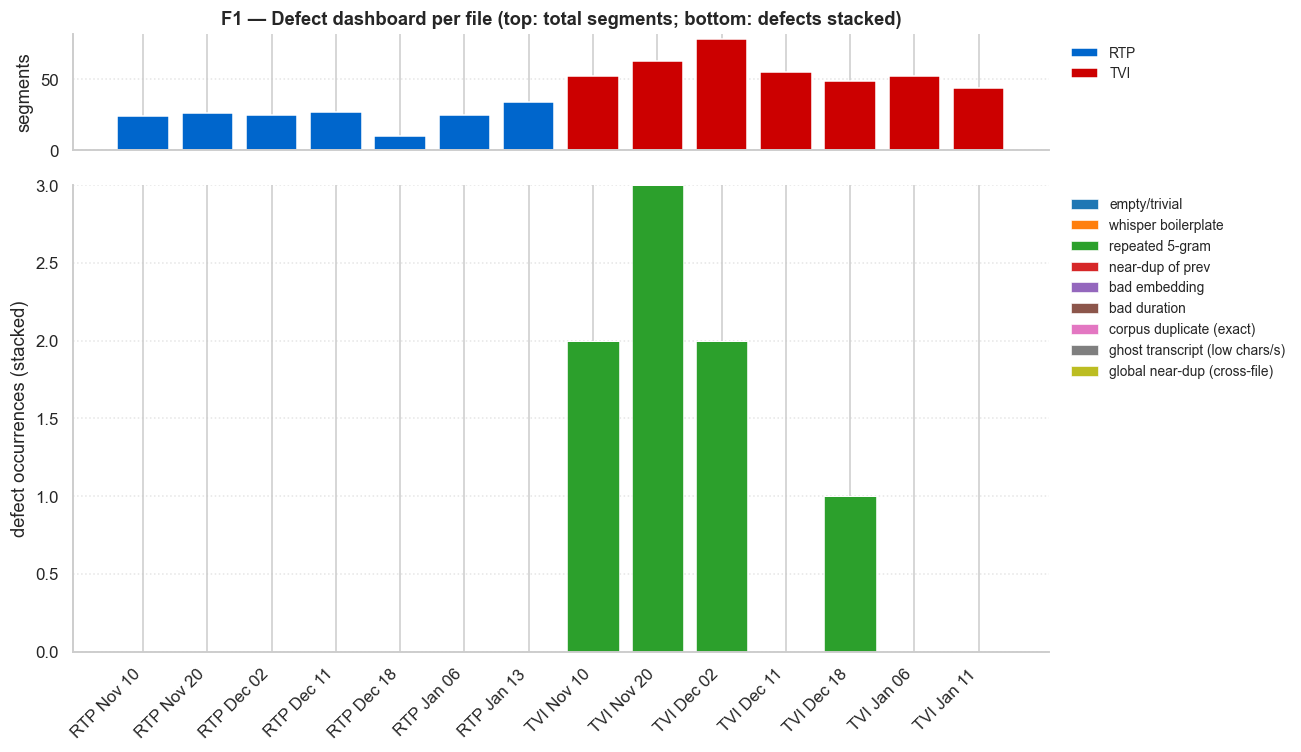

saved: <PROJECT_ROOT>/artifacts/figures/f1_defect_dashboard.png


In [13]:
# Aggregate defect counts per file, preserving channel + date for ordering/labels
_file_order = (
    speech_meta[["source_file", "channel", "date"]]
    .drop_duplicates()
    .sort_values(["channel", "date"])
    .reset_index(drop=True)
)

_defect_per_file = (
    speech_meta.groupby("source_file")[DEFECT_COLS].sum()
    .reindex(_file_order["source_file"])
    .fillna(0)
    .astype(int)
)

# Friendly labels: e.g. "RTP Nov 10"
_short_labels = (
    _file_order.assign(label=lambda d: d["channel"] + " " + d["date"].dt.strftime("%b %d"))
    ["label"].tolist()
)
_bar_colors = [CHANNEL_COLORS[c] for c in _file_order["channel"]]

# Distinct color per defect type (qualitative). tab10 tops out at 10 - we have 9.
_defect_palette = sns.color_palette("tab10", n_colors=len(DEFECT_COLS))
_defect_label = {
    "flag_empty": "empty/trivial",
    "flag_whisper": "whisper boilerplate",
    "flag_repeated_ngram": "repeated 5-gram",
    "flag_near_dup_prev": "near-dup of prev",
    "flag_bad_embedding": "bad embedding",
    "flag_bad_duration": "bad duration",
    "flag_corpus_duplicate": "corpus duplicate (exact)",
    "flag_ghost_transcript": "ghost transcript (low chars/s)",
    "flag_global_near_dup": "global near-dup (cross-file)",
}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": [1, 4]},
)

# Top strip: total segments per file, colored by channel
_seg_counts = speech_meta.groupby("source_file").size().reindex(_file_order["source_file"])
ax_top.bar(range(len(_file_order)), _seg_counts.to_numpy(),
           color=_bar_colors, edgecolor="white")
ax_top.set_ylabel("segments")
ax_top.set_title("F1 - Defect dashboard per file (top: total segments; bottom: defects stacked)")
ax_top.grid(axis="y", linestyle=":", alpha=0.5)

# Bottom: stacked defects
_x = np.arange(len(_file_order))
_bottom = np.zeros(len(_file_order))
for col, color in zip(DEFECT_COLS, _defect_palette):
    vals = _defect_per_file[col].to_numpy()
    ax_bot.bar(_x, vals, bottom=_bottom, label=_defect_label[col],
               color=color, edgecolor="white", linewidth=0.4)
    _bottom += vals

ax_bot.set_xticks(_x)
ax_bot.set_xticklabels(_short_labels, rotation=45, ha="right")
ax_bot.set_ylabel("defect occurrences (stacked)")
ax_bot.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
ax_bot.grid(axis="y", linestyle=":", alpha=0.5)

# Channel legend on top axis
from matplotlib.patches import Patch
ax_top.legend(handles=[Patch(facecolor=v, label=k) for k, v in CHANNEL_COLORS.items()],
              loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)

fig.tight_layout()
_fig_path = save_fig(fig, "f1_defect_dashboard")
plt.show()
print(f"saved: {_fig_path}")

In [14]:
_total = len(speech_meta)
_n_clean = int(speech_meta["is_clean"].sum())
_n_dirty = _total - _n_clean

print("=" * 64)
print(" SECTION 2 - QUALITY AUDIT SUMMARY")
print("=" * 64)
print(f" total segments        : {_total}")
print(f" clean segments        : {_n_clean}  ({100 * _n_clean / _total:.1f}%)")
print(f" flagged segments      : {_n_dirty}  ({100 * _n_dirty / _total:.1f}%)")
print()
print(" defect rate by type:")
for col in DEFECT_COLS:
    n = int(speech_meta[col].sum())
    print(f"   {_defect_label[col]:<22s} {n:>4d}   ({100 * n / _total:5.2f}%)")
print()

# Per-channel clean rate
_chan = (
    speech_meta.groupby("channel")
    .agg(segments=("is_clean", "size"),
         clean=("is_clean", "sum"))
    .assign(clean_rate=lambda d: (100 * d["clean"] / d["segments"]).round(1))
)
print(" per-channel clean rate:")
print(_chan.to_string())
print()

# Show a few examples per defect type for the report
def _examples(col, k=2):
    sub = speech_meta[speech_meta[col]][["channel", "date_raw", "segment_idx", "transcript"]]
    if sub.empty:
        return f"   ({_defect_label[col]}) - none"
    rows = []
    for _, r in sub.head(k).iterrows():
        snippet = r["transcript"][:120].replace("\n", " ")
        rows.append(f"   ({_defect_label[col]}) {r['channel']} {r['date_raw']} #{r['segment_idx']}: {snippet!r}")
    return "\n".join(rows)

print(" sample flagged segments:")
for col in DEFECT_COLS:
    print(_examples(col, k=2))
print("=" * 64)

CLEANED_PATH = ARTIFACTS_DIR / "cleaned_segments.parquet"
speech_meta.to_parquet(CLEANED_PATH, index=False)
print(f"\nwrote: {CLEANED_PATH}  ({CLEANED_PATH.stat().st_size / 1024:.1f} KiB)")

 SECTION 2 — QUALITY AUDIT SUMMARY
 total segments        : 564
 clean segments        : 556  (98.6%)
 flagged segments      : 8  (1.4%)

 defect rate by type:
   empty/trivial             0   ( 0.00%)
   whisper boilerplate       0   ( 0.00%)
   repeated 5-gram           8   ( 1.42%)
   near-dup of prev          0   ( 0.00%)
   bad embedding             0   ( 0.00%)
   bad duration              0   ( 0.00%)
   corpus duplicate (exact)    0   ( 0.00%)
   ghost transcript (low chars/s)    0   ( 0.00%)
   global near-dup (cross-file)    0   ( 0.00%)

 per-channel clean rate:
         segments  clean  clean_rate
channel                             
RTP           171    171       100.0
TVI           393    385        98.0

 sample flagged segments:
   (empty/trivial) — none
   (whisper boilerplate) — none
   (repeated 5-gram) TVI Nov_10 #27: ' Esta medida vem a elevar os forços das famílias por agora, poderá aliviar mais uma quinze e nem muito bem, mas eventual'
   (repeated 5-gram) TVI No

## 2.5 Manual review of flagged segments

The repeated-5-gram check flagged 8 segments. We read each one and classified it as:
- Whisper loop (model failure, dropped)
- Off-topic promo (lottery or ad content, dropped)
- Legitimate rhetoric (anaphora in real speech, kept)

This adds a `manual_verdict` column and a `flag_off_topic_promo` column, then recomputes `is_clean`.


In [15]:
MANUAL_VERDICTS = {
    ("Telejornal_TVI_Nov_10_speech.pkl", 27): "whisper_loop",     # 'se se se se se' x4 (8 in a row)
    ("Telejornal_TVI_Nov_10_speech.pkl", 51): "off_topic_promo",  # lottery: '30 mil euros em cartão'
    ("Telejornal_TVI_Nov_20_speech.pkl", 26): "whisper_loop",     # 'não' x17
    ("Telejornal_TVI_Nov_20_speech.pkl", 33): "whisper_loop",     # invented 'prenação' looped x4
    ("Telejornal_TVI_Nov_20_speech.pkl", 41): "legit_rhetoric",   # 'são mais vezes vítimas de ...'
    ("Telejornal_TVI_Dec_2_speech.pkl",  17): "whisper_loop",     # 'não' x8 mid-sentence
    ("Telejornal_TVI_Dec_2_speech.pkl",  63): "whisper_loop",     # multiple loops, severe
    ("Telejornal_TVI_Dec_18_speech.pkl", 48): "off_topic_promo",  # lottery: 'ligar 7 6 1 200 500'
}

_flagged_keys = set(
    speech_meta.loc[speech_meta["flag_repeated_ngram"], ["source_file", "segment_idx"]]
    .itertuples(index=False, name=None)
)
_verdict_keys = set(MANUAL_VERDICTS.keys())
assert _verdict_keys == _flagged_keys, (
    f"Verdict keys do not match flagged rows.\n"
    f"  in flags but not in verdicts: {_flagged_keys - _verdict_keys}\n"
    f"  in verdicts but not in flags: {_verdict_keys - _flagged_keys}"
)

# Apply verdicts
_key = list(zip(speech_meta["source_file"], speech_meta["segment_idx"]))
speech_meta["manual_verdict"] = pd.Series(
    [MANUAL_VERDICTS.get(k, "") for k in _key],
    index=speech_meta.index, dtype="string",
)

# New defect type: off-topic promotional content (correct transcript, wrong content)
speech_meta["flag_off_topic_promo"] = speech_meta["manual_verdict"].eq("off_topic_promo").to_numpy()

_is_legit = speech_meta["manual_verdict"].eq("legit_rhetoric").to_numpy()
_other_auto_flags = (
    speech_meta["flag_empty"]
    | speech_meta["flag_whisper"]
    | speech_meta["flag_near_dup_prev"]
    | speech_meta["flag_bad_embedding"]
    | speech_meta["flag_bad_duration"]
    | speech_meta["flag_corpus_duplicate"]
    | speech_meta["flag_ghost_transcript"]
    | speech_meta["flag_global_near_dup"]
).to_numpy()
_repeated_ngram_dirty = (
    speech_meta["flag_repeated_ngram"].to_numpy() & ~_is_legit
)
speech_meta["is_clean"] = ~(_other_auto_flags | _repeated_ngram_dirty | speech_meta["flag_off_topic_promo"].to_numpy())

# Summary
_total = len(speech_meta)
_n_clean = int(speech_meta["is_clean"].sum())
_verdict_counts = speech_meta["manual_verdict"].value_counts(dropna=False)

print("=" * 64)
print(" SECTION 2.5 - MANUAL ADJUDICATION")
print("=" * 64)
print(f" reviewed segments    : {len(MANUAL_VERDICTS)}")
print(f" verdict breakdown    :")
for verdict, n in _verdict_counts.items():
    if verdict and verdict != "":
        print(f"   {verdict:<18s} {int(n)}")
print()
print(f" before manual review : {_total - 8} clean / {_total} total  (8 auto-flagged on 5-gram)")
print(f" after  manual review : {_n_clean} clean / {_total} total")
print(f"   - kept (legit rhetoric)       : +1")
print(f"   - newly excluded (off-topic)  : -2")
print(f"   - plus any rows caught only by checks 8/9 (ghost / global near-dup)")
print()
print(" final dropped segments:")
_dropped = speech_meta.loc[~speech_meta["is_clean"], [
    "channel", "date_raw", "segment_idx", "manual_verdict",
    "flag_ghost_transcript", "flag_global_near_dup", "source_file",
]]
print(_dropped.to_string(index=False))
print("=" * 64)

# Re-save the cleaned-segments artifact with the new columns
CLEANED_PATH = ARTIFACTS_DIR / "cleaned_segments.parquet"
speech_meta.to_parquet(CLEANED_PATH, index=False)
print(f"\nupdated: {CLEANED_PATH}  ({CLEANED_PATH.stat().st_size / 1024:.1f} KiB)")

 SECTION 2.5 — MANUAL ADJUDICATION
 reviewed segments    : 8
 verdict breakdown    :
   whisper_loop       5
   off_topic_promo    2
   legit_rhetoric     1

 before manual review : 556 clean / 564 total  (8 auto-flagged on 5-gram)
 after  manual review : 557 clean / 564 total
   - kept (legit rhetoric)       : +1
   - newly excluded (off-topic)  : -2
   - plus any rows caught only by checks 8/9 (ghost / global near-dup)

 final dropped segments:
channel date_raw  segment_idx  manual_verdict  flag_ghost_transcript  flag_global_near_dup                      source_file
    TVI   Nov_10           27    whisper_loop                  False                 False Telejornal_TVI_Nov_10_speech.pkl
    TVI   Nov_10           51 off_topic_promo                  False                 False Telejornal_TVI_Nov_10_speech.pkl
    TVI   Nov_20           26    whisper_loop                  False                 False Telejornal_TVI_Nov_20_speech.pkl
    TVI   Nov_20           33    whisper_loop        

## 2.6 Ad and promo detection

Section 2.5 only caught ads that happened to repeat a phrase. Here we also look for promos that do not repeat:
phone-in lottery reads, call-to-action spots, and sponsorship mentions.
Hard signals (premium phone numbers, "ligar para o", "euros em cartao", "sorteio") and soft signals
(currency amounts, imperatives, "so hoje") flag candidates, which we then review by hand.
Of 9 candidates, 3 are real promos and 6 are regular news that used ad-like numbers.


In [16]:
# Hard signals: high precision for paid content
PROMO_PHONE_RE = re.compile(r"\b\d[\d\s,\.\-]{5,}\d\b")
PROMO_LIGAR_RE = re.compile(r"\b(ligar para o|ligue (?:já|agora)|marque o número|ligar agora)\b", re.I)
PROMO_EUROS_AD_RE = re.compile(r"\b(euros em cart[aã]o|sorteio|passatempo|concurso (?:de|tv|tvi))\b", re.I)
# Soft signals: appear in journalism too - only useful when stacked
PROMO_CURRENCY_RE = re.compile(r"\b\d+(?:[.,]\d+)?\s*(?:mil\s*)?(?:euros|€)\b", re.I)
PROMO_IMPERATIVE_RE = re.compile(r"\b(ligue|participe|compre|aproveite|garanta|n[ãa]o perca|inscreva-se)\b", re.I)
PROMO_LOTTERY_RE = re.compile(r"\b(pr[ée]mio|sorteio|concurso|passatempo|loteria)\b", re.I)
PROMO_MKT_RE = re.compile(r"\b(s[óo] hoje|promo[çc][ãa]o|exclusivo|gratuito|melhor forma de)\b", re.I)

def promo_score(text: str) -> dict:
    return {
        "phone":      len(PROMO_PHONE_RE.findall(text)),
        "ligar":      len(PROMO_LIGAR_RE.findall(text)),
        "euros_ad":   len(PROMO_EUROS_AD_RE.findall(text)),
        "currency":   len(PROMO_CURRENCY_RE.findall(text)),
        "imperative": len(PROMO_IMPERATIVE_RE.findall(text)),
        "lottery":    len(PROMO_LOTTERY_RE.findall(text)),
        "mkt":        len(PROMO_MKT_RE.findall(text)),
    }

def _hard_soft(s: dict) -> tuple[int, int]:
    hard = (s["phone"] >= 1) + (s["ligar"] >= 1) + (s["euros_ad"] >= 1)
    soft = (s["currency"] >= 1) + (s["imperative"] >= 1) + (s["lottery"] >= 2) + (s["mkt"] >= 1)
    return hard, soft

_promo_rows = []
for i, r in speech_meta.iterrows():
    s = promo_score(r["transcript"])
    h, sf = _hard_soft(s)
    if h >= 1 or sf >= 2:
        _promo_rows.append({
            "row": i, "channel": r["channel"], "date_raw": r["date_raw"],
            "segment_idx": r["segment_idx"], "source_file": r["source_file"],
            "hard": h, "soft": sf,
            "phone": s["phone"], "ligar": s["ligar"], "euros_ad": s["euros_ad"],
            "currency": s["currency"], "imperative": s["imperative"],
            "lottery": s["lottery"], "mkt": s["mkt"],
            "prior_is_clean": bool(r["is_clean"]),
            "prior_verdict": str(r["manual_verdict"]),
        })

promo_candidates = (
    pd.DataFrame(_promo_rows)
    .sort_values(["hard", "soft"], ascending=False)
    .reset_index(drop=True)
)
print(f"promo candidates: {len(promo_candidates)}")
print(promo_candidates.to_string(index=False))

promo candidates: 9
 row channel date_raw  segment_idx                      source_file  hard  soft  phone  ligar  euros_ad  currency  imperative  lottery  mkt  prior_is_clean   prior_verdict
 222     TVI   Nov_10           51 Telejornal_TVI_Nov_10_speech.pkl     3     1      2      2         3         5           0        0    0           False off_topic_promo
 467     TVI   Dec_18           48 Telejornal_TVI_Dec_18_speech.pkl     1     2      3      0         0         2           0        0    1           False off_topic_promo
 363     TVI    Dec_2           77  Telejornal_TVI_Dec_2_speech.pkl     1     1      5      0         0         2           0        0    0            True                
 510     TVI    Jan_6           42  Telejornal_TVI_Jan_6_speech.pkl     1     1      1      0         0         1           0        0    0            True                
   0     RTP   Nov_10            0 Telejornal_RTP_Nov_10_speech.pkl     1     0      1      0         0         0       

In [17]:
PROMO_VERDICTS = {
    ("Telejornal_TVI_Nov_10_speech.pkl", 51): "off_topic_promo",  # already in 2.5 - confirmed
    ("Telejornal_TVI_Dec_18_speech.pkl", 48): "off_topic_promo",  # already in 2.5 - confirmed
    ("Telejornal_TVI_Dec_2_speech.pkl",  77): "off_topic_promo",  # NEW: lottery '761, 250 ... meio milhão de euros'
    ("Telejornal_TVI_Jan_6_speech.pkl",  42): "news_content",     # APH financial report; '520.179 euros' is a news figure
    ("Telejornal_RTP_Nov_10_speech.pkl",  0): "news_content",     # 100.000 trabalhadores na rua
    ("Telejornal_TVI_Nov_20_speech.pkl", 39): "news_content",     # 151.647 acidentes (PSP/GNR statistics)
    ("Telejornal_TVI_Jan_6_speech.pkl",   7): "news_content",     # 111.974 mortes (mortality stats)
    ("Telejornal_TVI_Nov_10_speech.pkl", 39): "news_content",     # hospital corruption story; 'exclusivo da TVI' branding
    ("Telejornal_TVI_Jan_6_speech.pkl",  41): "news_content",     # APH patrocínios; same exclusivo branding
}

_cand_keys = set(zip(promo_candidates["source_file"], promo_candidates["segment_idx"]))
_verdict_keys = set(PROMO_VERDICTS.keys())
assert _verdict_keys == _cand_keys, (
    f"Promo verdict keys mismatch.\n"
    f"  in candidates but not classified: {_cand_keys - _verdict_keys}\n"
    f"  in verdicts but not in candidates: {_verdict_keys - _cand_keys}"
)

# Apply: extend `manual_verdict` with the new promo we found, recompute
# `flag_off_topic_promo` and `is_clean`.
for (src, seg), verdict in PROMO_VERDICTS.items():
    if verdict == "off_topic_promo":
        mask = (speech_meta["source_file"] == src) & (speech_meta["segment_idx"] == seg)
        speech_meta.loc[mask, "manual_verdict"] = "off_topic_promo"

speech_meta["flag_off_topic_promo"] = speech_meta["manual_verdict"].eq("off_topic_promo").to_numpy()

# Recompute is_clean exactly as in Section 2.5, now using the updated promo flag.
# Include all auto-flags from Section 2.2 (including ghost_transcript and global_near_dup).
_is_legit = speech_meta["manual_verdict"].eq("legit_rhetoric").to_numpy()
_other_auto_flags = (
    speech_meta["flag_empty"]
    | speech_meta["flag_whisper"]
    | speech_meta["flag_near_dup_prev"]
    | speech_meta["flag_bad_embedding"]
    | speech_meta["flag_bad_duration"]
    | speech_meta["flag_corpus_duplicate"]
    | speech_meta["flag_ghost_transcript"]
    | speech_meta["flag_global_near_dup"]
).to_numpy()
_repeated_ngram_dirty = speech_meta["flag_repeated_ngram"].to_numpy() & ~_is_legit
speech_meta["is_clean"] = ~(
    _other_auto_flags
    | _repeated_ngram_dirty
    | speech_meta["flag_off_topic_promo"].to_numpy()
)

# Summary
_total = len(speech_meta)
_n_promo = int(speech_meta["flag_off_topic_promo"].sum())
_n_clean = int(speech_meta["is_clean"].sum())
_new_promo_keys = [
    k for k, v in PROMO_VERDICTS.items()
    if v == "off_topic_promo" and k not in {
        ("Telejornal_TVI_Nov_10_speech.pkl", 51),
        ("Telejornal_TVI_Dec_18_speech.pkl", 48),
    }
]

print("=" * 64)
print(" SECTION 2.6 - TARGETED PROMO DETECTION")
print("=" * 64)
print(f" candidates flagged by regex   : {len(PROMO_VERDICTS)}")
print(f" confirmed promos (total)      : {_n_promo}")
print(f"   already labeled in 2.5      : 2")
print(f"   newly identified in 2.6     : {len(_new_promo_keys)}")
for k in _new_promo_keys:
    print(f"     -> {k[0]}  segment #{k[1]}")
print(f" false positives (news content): {sum(1 for v in PROMO_VERDICTS.values() if v == 'news_content')}")
print()
print(f" after 2.6 adjudication: {_n_clean} clean / {_total}")
print()

# Per-channel impact
_chan = (
    speech_meta.groupby("channel")
    .agg(segments=("is_clean", "size"),
         clean=("is_clean", "sum"),
         promos=("flag_off_topic_promo", "sum"))
)
_chan["clean_rate_%"] = (100 * _chan["clean"] / _chan["segments"]).round(1)
print(" per-channel after promo cleanup:")
print(_chan.to_string())
print("=" * 64)

CLEANED_PATH = ARTIFACTS_DIR / "cleaned_segments.parquet"
speech_meta.to_parquet(CLEANED_PATH, index=False)
print(f"\nupdated: {CLEANED_PATH}  ({CLEANED_PATH.stat().st_size / 1024:.1f} KiB)")

 SECTION 2.6 — TARGETED PROMO DETECTION
 candidates flagged by regex   : 9
 confirmed promos (total)      : 3
   already labeled in 2.5      : 2
   newly identified in 2.6     : 1
     -> Telejornal_TVI_Dec_2_speech.pkl  segment #77
 false positives (news content): 6

 after 2.6 adjudication: 556 clean / 564

 per-channel after promo cleanup:
         segments  clean  promos  clean_rate_%
channel                                       
RTP           171    171       0         100.0
TVI           393    385       3          98.0

updated: artifacts/cleaned_segments.parquet  (256.2 KiB)


## 2.7 Source-capture check

Some recordings only captured part of the broadcast. Full newscasts run about 45-50 minutes,
so any file with a span under 25 minutes is flagged as `is_partial_capture`.
These rows stay in the table but Sections 3, 4, and 6 exclude them so comparisons use full episodes only.


In [18]:
PARTIAL_CAPTURE_MIN_SPAN_SEC = 25 * 60

# Compute per-file span and density from `speech_meta` itself, so this is
# reproducible from `cleaned_segments.parquet` without re-loading the pkls.
_end_sec = speech_meta["timestamp"] + speech_meta["duration"]
_per_file = (
    pd.DataFrame({
        "source_file": speech_meta["source_file"],
        "channel":     speech_meta["channel"],
        "start":       speech_meta["timestamp"],
        "end":         _end_sec,
        "duration":    speech_meta["duration"],
    })
    .groupby(["source_file", "channel"], as_index=False)
    .agg(
        n_seg=("duration", "size"),
        first_start=("start", "min"),
        last_end=("end", "max"),
        speech_sec=("duration", "sum"),
    )
)
_per_file["span_sec"]           = _per_file["last_end"] - _per_file["first_start"]
_per_file["span_min"]           = (_per_file["span_sec"] / 60).round(1)
_per_file["density"]            = (_per_file["speech_sec"] / _per_file["span_sec"]).round(3)
_per_file["is_partial_capture"] = _per_file["span_sec"] < PARTIAL_CAPTURE_MIN_SPAN_SEC

print("=" * 78)
print(" SECTION 2.7 - SOURCE-CAPTURE SANITY CHECK")
print("=" * 78)
print(f" rule: is_partial_capture = (video_span < {PARTIAL_CAPTURE_MIN_SPAN_SEC // 60} min)")
print()
print(
    _per_file.sort_values("span_sec")
    [["channel", "source_file", "n_seg", "span_min", "density", "is_partial_capture"]]
    .to_string(index=False)
)
print()

# Apply the per-file flag back to every row of those files in speech_meta.
_partial_files = set(_per_file.loc[_per_file["is_partial_capture"], "source_file"])
speech_meta["is_partial_capture"] = speech_meta["source_file"].isin(_partial_files)

n_partial_files = len(_partial_files)
n_partial_rows  = int(speech_meta["is_partial_capture"].sum())
print(f" partial-capture files : {n_partial_files}")
for f in sorted(_partial_files):
    sub = _per_file[_per_file["source_file"] == f].iloc[0]
    print(f"   - {f}  span={sub['span_min']:.1f} min  "
          f"density={sub['density']:.3f}  n_seg={int(sub['n_seg'])}")
print(f" rows flagged          : {n_partial_rows}  "
      f"(of which {int((speech_meta['is_partial_capture'] & speech_meta['is_clean']).sum())} "
      f"were `is_clean=True` and will be dropped from comparative analysis)")
print(f" effect on `is_clean`  : 0 segments - these transcripts are individually fine,")
print(f"                          they just don't represent a complete broadcast.")
print("=" * 78)

speech_meta.to_parquet(CLEANED_PATH, index=False)
print(f"\nupdated: {CLEANED_PATH}  ({CLEANED_PATH.stat().st_size / 1024:.1f} KiB)")

 SECTION 2.7 — SOURCE-CAPTURE SANITY CHECK
 rule: is_partial_capture = (video_span < 25 min)

channel                      source_file  n_seg  span_min  density  is_partial_capture
    RTP Telejornal_RTP_Dec_18_speech.pkl     10      18.7    0.258                True
    RTP Telejornal_RTP_Nov_10_speech.pkl     24      37.5    0.352               False
    RTP Telejornal_RTP_Nov_20_speech.pkl     26      38.1    0.394               False
    RTP  Telejornal_RTP_Dec_2_speech.pkl     25      44.6    0.493               False
    RTP Telejornal_RTP_Dec_11_speech.pkl     27      45.2    0.474               False
    RTP  Telejornal_RTP_Jan_6_speech.pkl     25      47.7    0.380               False
    RTP Telejornal_RTP_Jan_13_speech.pkl     34      49.5    0.439               False
    TVI  Telejornal_TVI_Jan_6_speech.pkl     52      60.4    0.589               False
    TVI Telejornal_TVI_Jan_11_speech.pkl     44      64.0    0.425               False
    TVI Telejornal_TVI_Dec_11_speech

## 3. Temporal structure

Using the clean, full-episode subset, we look at segment lengths per channel,
where speech sits within each video, and total speech per broadcast.
Results saved to `artifacts/temporal_summary.parquet`.


is_clean == True            : 556 / 564 (98.6%)
  & ~is_partial_capture     : 546 / 564 (96.8%)  ← used in Section 3 / 4
  dropped as partial capture: 10 segments (from 1 file(s))

duration (s) — per channel:
         count   mean  median    std    min     max
channel                                            
RTP        161  41.53   29.50  30.75  20.03  182.62
TVI        385  40.59   32.05  26.42  20.15  203.58


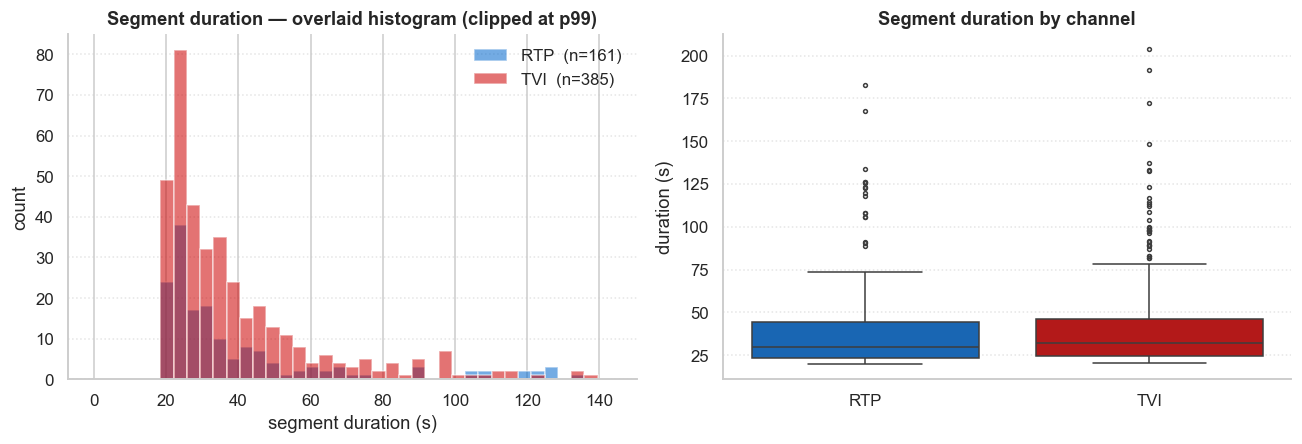

In [19]:
_full_episode = ~speech_meta["is_partial_capture"]
clean = speech_meta.loc[speech_meta["is_clean"] & _full_episode].copy()
assert clean["timestamp"].notna().all() and clean["duration"].notna().all(), \
    "Section 3 assumes timestamp/duration are populated for clean rows."

n_total          = len(speech_meta)
n_is_clean       = int(speech_meta["is_clean"].sum())
n_after_partial  = len(clean)
print(f"is_clean == True            : {n_is_clean} / {n_total} "
      f"({100 * n_is_clean / n_total:.1f}%)")
print(f"  & ~is_partial_capture     : {n_after_partial} / {n_total} "
      f"({100 * n_after_partial / n_total:.1f}%)  ← used in Section 3 / 4")
print(f"  dropped as partial capture: {n_is_clean - n_after_partial} segments "
      f"(from {speech_meta.loc[speech_meta['is_partial_capture'], 'source_file'].nunique()} file(s))")

print("\nduration (s) - per channel:")
print(
    clean.groupby("channel")["duration"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .to_string()
)

fig, (ax_h, ax_b) = plt.subplots(1, 2, figsize=(12, 4.2))

_bins = np.linspace(0, clean["duration"].quantile(0.99), 40)
for ch, sub in clean.groupby("channel"):
    ax_h.hist(
        sub["duration"], bins=_bins, alpha=0.55,
        color=CHANNEL_COLORS[ch], edgecolor="white", label=f"{ch}  (n={len(sub)})",
    )
ax_h.set_xlabel("segment duration (s)")
ax_h.set_ylabel("count")
ax_h.set_title("Segment duration - overlaid histogram (clipped at p99)")
ax_h.legend(frameon=False)
ax_h.grid(axis="y", linestyle=":", alpha=0.5)

sns.boxplot(
    data=clean, x="channel", y="duration",
    hue="channel", palette=CHANNEL_COLORS, ax=ax_b,
    order=["RTP", "TVI"], legend=False, fliersize=2.5, linewidth=1.0,
)
ax_b.set_title("Segment duration by channel")
ax_b.set_xlabel("")
ax_b.set_ylabel("duration (s)")
ax_b.grid(axis="y", linestyle=":", alpha=0.5)

fig.tight_layout()
plt.show()

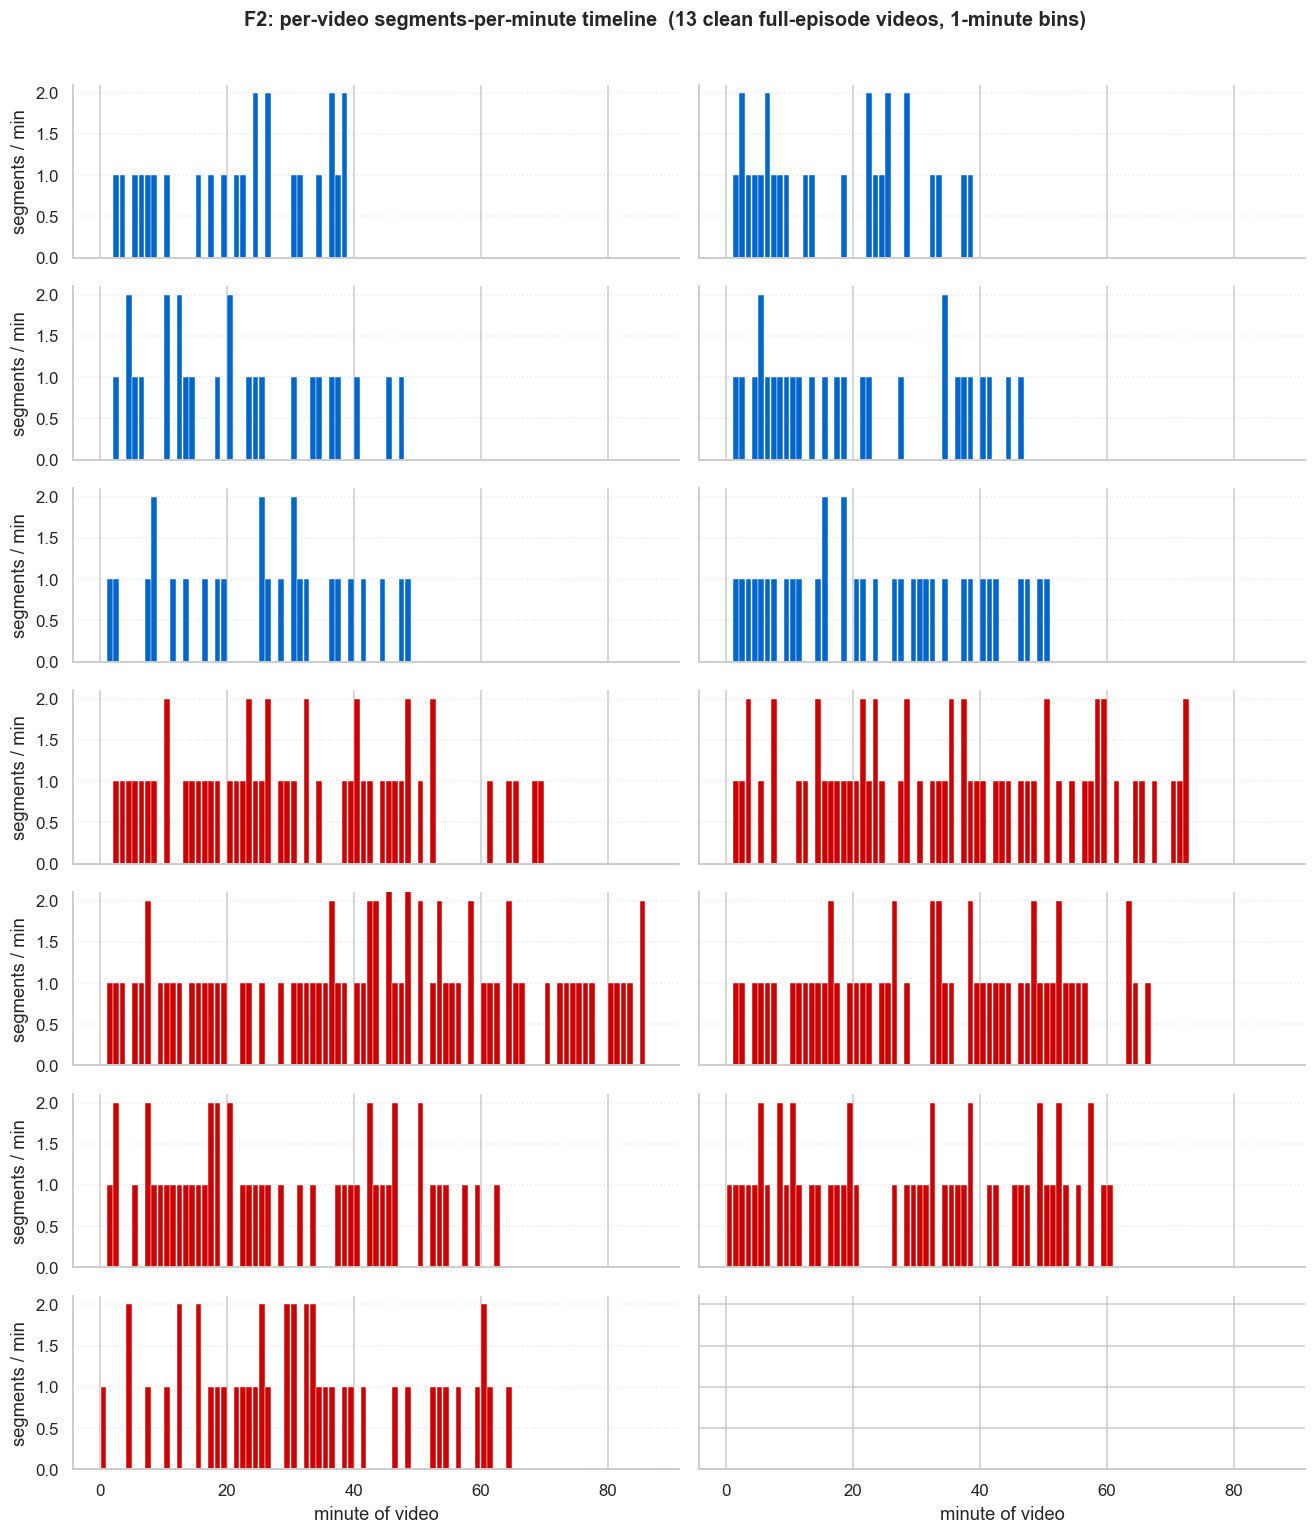

saved: <PROJECT_ROOT>/artifacts/figures/f2_segments_per_minute.png


In [20]:
# Order videos: by channel (RTP first, then TVI), then by air date
_videos = (
    clean[["source_file", "channel", "date"]]
    .drop_duplicates()
    .sort_values(["channel", "date"])
    .reset_index(drop=True)
)
_n_videos = len(_videos)
assert _n_videos == clean["source_file"].nunique(), (
    f"video-row count mismatch: {_n_videos} vs {clean['source_file'].nunique()}"
)

# Choose a 2-column grid; rows = ceil(n / 2).
_n_cols = 2
_n_rows = (_n_videos + _n_cols - 1) // _n_cols

# A common x-axis upper bound makes the panels visually comparable
_video_span_s = (
    clean.assign(end=clean["timestamp"] + clean["duration"])
         .groupby("source_file")["end"].max()
)
_xmax_min = float(np.ceil(_video_span_s.max() / 60.0))

fig, axes = plt.subplots(_n_rows, _n_cols, figsize=(12, 2 * _n_rows),
                         sharex=True, sharey=True)
_axflat = axes.flat if hasattr(axes, "flat") else [axes]

for ax, (_, vid) in zip(_axflat, _videos.iterrows()):
    sub = clean[clean["source_file"] == vid["source_file"]]
    minute = (sub["timestamp"].to_numpy() / 60.0).astype(float)
    bins = np.arange(0, _xmax_min + 1, 1)
    counts, edges = np.histogram(minute, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    color = CHANNEL_COLORS[vid["channel"]]
    ax.bar(centers, counts, width=0.9, color=color, edgecolor="white", linewidth=0.3)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.set_ylim(bottom=0)

# Hide any unused panels (when _n_videos < _n_rows * _n_cols)
for ax in list(_axflat)[_n_videos:]:
    ax.set_visible(False)

# Shared axis labels (apply to bottom row of visible panels and left column)
_axes2d = np.atleast_2d(axes)
for ax in _axes2d[-1, :]:
    ax.set_xlabel("minute of video")
for ax in _axes2d[:, 0]:
    ax.set_ylabel("segments / min")

fig.suptitle(
    f"F2: per-video segments-per-minute timeline  "
    f"({_n_videos} clean full-episode videos, 1-minute bins)",
    fontsize=13, fontweight="bold", y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.985))
_fig_path = save_fig(fig, "f2_segments_per_minute")
plt.show()
print(f"saved: {_fig_path}")

In [21]:
_clean = clean.assign(end=clean["timestamp"] + clean["duration"])

temporal_summary = (
    _clean.groupby(["channel", "date", "source_file"], as_index=False)
    .agg(
        segment_count=("segment_idx", "size"),
        total_speech_sec=("duration", "sum"),
        mean_duration_sec=("duration", "mean"),
        median_duration_sec=("duration", "median"),
        first_start_sec=("timestamp", "min"),
        last_end_sec=("end", "max"),
    )
)
temporal_summary["video_span_sec"] = (
    temporal_summary["last_end_sec"] - temporal_summary["first_start_sec"]
)
temporal_summary["total_speech_min"] = temporal_summary["total_speech_sec"] / 60.0
temporal_summary["speech_density"] = (
    temporal_summary["total_speech_sec"] / temporal_summary["video_span_sec"]
)

temporal_summary = (
    temporal_summary[[
        "channel", "date", "source_file",
        "segment_count",
        "total_speech_sec", "total_speech_min",
        "mean_duration_sec", "median_duration_sec",
        "video_span_sec", "speech_density",
    ]]
    .sort_values(["channel", "date"])
    .reset_index(drop=True)
)

TEMPORAL_PATH = ARTIFACTS_DIR / "temporal_summary.parquet"
temporal_summary.to_parquet(TEMPORAL_PATH, index=False)

_view = temporal_summary.copy()
_view["date"] = _view["date"].dt.strftime("%b %d")
_view = _view.round({
    "total_speech_sec": 1, "total_speech_min": 2,
    "mean_duration_sec": 2, "median_duration_sec": 2,
    "video_span_sec": 1, "speech_density": 3,
})

print("=" * 78)
print(" SECTION 3 - TEMPORAL SUMMARY (one row per video, clean segments only)")
print("=" * 78)
print(_view.drop(columns=["source_file"]).to_string(index=False))
print()
print(" per-channel aggregate:")
print(
    temporal_summary.groupby("channel")
    .agg(
        videos=("source_file", "nunique"),
        segments=("segment_count", "sum"),
        speech_min=("total_speech_min", "sum"),
        mean_dur=("mean_duration_sec", "mean"),
        median_dur=("median_duration_sec", "mean"),
        density=("speech_density", "mean"),
    )
    .round({"speech_min": 1, "mean_dur": 2, "median_dur": 2, "density": 3})
    .to_string()
)
print("=" * 78)
print(f"\nwrote: {TEMPORAL_PATH}  ({TEMPORAL_PATH.stat().st_size / 1024:.1f} KiB)")

 SECTION 3 — TEMPORAL SUMMARY (one row per video, clean segments only)
channel   date  segment_count  total_speech_sec  total_speech_min  mean_duration_sec  median_duration_sec  video_span_sec  speech_density
    RTP Nov 10             24             792.2             13.20              33.01                27.65          2252.0           0.352
    RTP Nov 20             26             899.9             15.00              34.61                25.76          2285.0           0.394
    RTP Dec 02             25            1318.3             21.97              52.73                32.13          2674.4           0.493
    RTP Dec 11             27            1286.8             21.45              47.66                34.98          2712.5           0.474
    RTP Jan 06             25            1085.8             18.10              43.43                24.37          2861.1           0.380
    RTP Jan 13             34            1303.7             21.73              38.34                2

## 4. Linguistic surface

What does each channel talk about? We tokenize and lemmatize every clean transcript
with `pt_core_news_md` (output cached to parquet), then compute:
top content lemmas, top content bigrams, and per-channel TF-IDF.
Stopwords are spaCy's Portuguese list plus a few high-frequency verbs and articles.
TTR is reported as a median because it is length-sensitive.


In [22]:
import hashlib
import json

# Stopwords: spaCy PT defaults + project-specific additions
EXTRA_STOPWORDS = {"é", "ser", "ter", "haver", "estar", "fazer",
                   "ir", "poder", "dizer", "e", "o", "a"}
PT_STOPWORDS = set(nlp.Defaults.stop_words) | EXTRA_STOPWORDS

TOKENIZATION_VERSION = 3  # v3: also exclude `is_partial_capture` files (§2.7)

clean_subset = (
    speech_meta.loc[speech_meta["is_clean"] & ~speech_meta["is_partial_capture"]]
    .assign(row_idx=lambda d: d.index)
    .reset_index(drop=True)
)
transcripts = clean_subset["transcript"].tolist()
print(f"clean transcripts to tokenize: {len(transcripts)}  "
      f"(after dropping is_partial_capture)")

_payload = ("\n".join(transcripts)
            + "|" + SPACY_MODEL
            + f"|v{TOKENIZATION_VERSION}"
            + "|" + ",".join(sorted(PT_STOPWORDS)))
CONTENT_HASH = hashlib.sha256(_payload.encode("utf-8")).hexdigest()[:16]

TOKENS_PATH = ARTIFACTS_DIR / "segments_tokens.parquet"
TOKENS_META_PATH = ARTIFACTS_DIR / "segments_tokens.meta.json"

def _extract_lemmas(doc) -> list[str]:
    """Lowercased alphabetic lemmas. Contracted forms (do, no, pelo, ...)
    are split so each piece can be matched against the stopword list."""
    out: list[str] = []
    for tok in doc:
        if not tok.is_alpha:
            continue
        for piece in tok.lemma_.lower().split():
            if piece.isalpha():
                out.append(piece)
    return out

_cache_hit = False
if TOKENS_PATH.exists() and TOKENS_META_PATH.exists():
    try:
        _meta = json.loads(TOKENS_META_PATH.read_text())
        if (_meta.get("content_hash") == CONTENT_HASH
                and _meta.get("n_segments") == len(clean_subset)):
            seg_tokens_df = pd.read_parquet(TOKENS_PATH)
            if len(seg_tokens_df) == len(clean_subset):
                _cache_hit = True
                print(f"[cache hit] loaded {len(seg_tokens_df)} segments from {TOKENS_PATH}")
    except Exception as e:
        print(f"[cache check failed] {e}")

if not _cache_hit:
    print(f"[cache miss] tokenizing with {SPACY_MODEL}...")
    rows = []
    # NER is not used in this section; disable to speed up the pipe.
    with nlp.select_pipes(disable=["ner"]):
        for i, doc in enumerate(nlp.pipe(transcripts, batch_size=32)):
            all_lemmas = _extract_lemmas(doc)
            content = [l for l in all_lemmas
                       if l not in PT_STOPWORDS and len(l) >= 2]
            n_all = len(all_lemmas)
            n_unique = len(set(all_lemmas))
            n_sent = sum(1 for _ in doc.sents)
            ttr = (n_unique / n_all) if n_all > 0 else 0.0
            row = clean_subset.iloc[i]
            rows.append({
                "row_idx": int(row["row_idx"]),
                "channel": row["channel"],
                "date": row["date"],
                "date_raw": row["date_raw"],
                "segment_idx": int(row["segment_idx"]),
                "source_file": row["source_file"],
                "tokens": content,            # content lemmas only (post-stopwords)
                "n_tokens": len(content),     # post-stopwords
                "n_tokens_all": n_all,        # all alphabetic lemmas (incl. stopwords)
                "n_sentences": n_sent,
                "type_token_ratio": round(ttr, 4),
            })
    seg_tokens_df = pd.DataFrame(rows)
    seg_tokens_df.to_parquet(TOKENS_PATH, index=False)
    TOKENS_META_PATH.write_text(json.dumps({
        "content_hash": CONTENT_HASH,
        "tokenization_version": TOKENIZATION_VERSION,
        "spacy_model": SPACY_MODEL,
        "spacy_version": spacy.__version__,
        "n_segments": len(seg_tokens_df),
        "n_extra_stopwords": len(EXTRA_STOPWORDS),
    }, indent=2))
    print(f"[cache write] saved {TOKENS_PATH}  "
          f"({TOKENS_PATH.stat().st_size / 1024:.1f} KiB)")

print(f"\nseg_tokens_df shape: {seg_tokens_df.shape}")
print(seg_tokens_df.drop(columns=["tokens"]).describe(include="all").round(2).to_string())

clean transcripts to tokenize: 546  (after dropping is_partial_capture)


[cache hit] loaded 546 segments from artifacts/segments_tokens.parquet

seg_tokens_df shape: (546, 11)
        row_idx channel                        date date_raw  segment_idx                      source_file  n_tokens  n_tokens_all  n_sentences  type_token_ratio
count    546.00     546                         546      546       546.00                              546    546.00        546.00       546.00            546.00
unique      NaN       2                         NaN        8          NaN                               13       NaN           NaN          NaN               NaN
top         NaN     TVI                         NaN    Dec_2          NaN  Telejornal_TVI_Dec_2_speech.pkl       NaN           NaN          NaN               NaN
freq        NaN     385                         NaN      100          NaN                               75       NaN           NaN          NaN               NaN
mean     284.42     NaN  2025-12-10 15:20:26.373626      NaN        23.78              

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 4.2.1 Top-30 content lemmas - overall + per channel
_all_tokens_flat = [t for toks in seg_tokens_df["tokens"] for t in toks]
top_lemmas_overall = Counter(_all_tokens_flat).most_common(30)

top_lemmas_per_channel = {}
for chan, sub in seg_tokens_df.groupby("channel"):
    flat = [t for toks in sub["tokens"] for t in toks]
    top_lemmas_per_channel[chan] = Counter(flat).most_common(30)

# 4.2.2 Top-30 content bigrams (no segment-boundary crossing)
def _bigrams(toks: list[str]) -> list[tuple[str, str]]:
    return list(zip(toks[:-1], toks[1:])) if len(toks) >= 2 else []

_all_bigrams_flat = [bg for toks in seg_tokens_df["tokens"] for bg in _bigrams(toks)]
top_bigrams = Counter(_all_bigrams_flat).most_common(30)

# 4.2.3 TF-IDF at the segment level
# document = content lemmas of one segment
_docs = [" ".join(toks) for toks in seg_tokens_df["tokens"]]
tfidf = TfidfVectorizer(
    token_pattern=r"\S+",  # tokens are already cleaned; split on whitespace
    min_df=2,              # drop singletons for stable IDF
    sublinear_tf=True,
)
X_tfidf = tfidf.fit_transform(_docs)
TFIDF_VOCAB = tfidf.get_feature_names_out()
print(f"TF-IDF: {X_tfidf.shape[0]} segments × {X_tfidf.shape[1]} terms")

# top distinctive terms per channel
_chan_mask = {c: (seg_tokens_df["channel"].to_numpy() == c) for c in ("RTP", "TVI")}
top_tfidf_per_channel: dict[str, list[tuple[str, float]]] = {}
for chan, mask in _chan_mask.items():
    if mask.sum() == 0:
        continue
    chan_mean = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(chan_mean)[::-1][:30]
    top_tfidf_per_channel[chan] = [
        (TFIDF_VOCAB[i], float(chan_mean[i])) for i in top_idx
    ]

# differential TF-IDF: RTP vs TVI
_rtp_mean = np.asarray(X_tfidf[_chan_mask["RTP"]].mean(axis=0)).ravel()
_tvi_mean = np.asarray(X_tfidf[_chan_mask["TVI"]].mean(axis=0)).ravel()
_diff = _rtp_mean - _tvi_mean
_distinctive_rtp = [(TFIDF_VOCAB[i], float(_diff[i]))
                    for i in np.argsort(_diff)[::-1][:20]]
_distinctive_tvi = [(TFIDF_VOCAB[i], float(-_diff[i]))
                    for i in np.argsort(_diff)[:20]]

print("\nTop-15 content lemmas (overall):")
print("  ", ", ".join(f"{w}({c})" for w, c in top_lemmas_overall[:15]))
print("\nTop-10 content bigrams:")
for bg, c in top_bigrams[:10]:
    print(f"  {' '.join(bg):<32s} {c}")
print("\nTop-10 TF-IDF terms - RTP:")
print("  ", ", ".join(w for w, _ in top_tfidf_per_channel.get("RTP", [])[:10]))
print("Top-10 TF-IDF terms - TVI:")
print("  ", ", ".join(w for w, _ in top_tfidf_per_channel.get("TVI", [])[:10]))
print("\nDistinctive of RTP (mean RTP - TVI, top 10):")
print("  ", ", ".join(w for w, _ in _distinctive_rtp[:10]))
print("Distinctive of TVI (mean TVI - RTP, top 10):")
print("  ", ", ".join(w for w, _ in _distinctive_tvi[:10]))

TF-IDF: 546 segments × 2300 terms

Top-15 content lemmas (overall):
   dia(172), ano(167), país(142), outro(138), pessoa(138), governo(129), presidente(117), algum(98), passar(96), querer(94), acontecer(87), ficar(82), achar(82), república(81), chegar(81)

Top-10 content bigrams:
  estados unidos                   52
  presidente república             35
  donald trump                     27
  milhão euro                      17
  pacote laboral                   17
  andré ventura                    16
  nacional saúde                   13
  ministério público               13
  serviço mínimo                   12
  candidato presidencial           12

Top-10 TF-IDF terms — RTP:
   governo, presidente, dia, debate, candidato, pessoa, sondagem, acontecer, república, volta
Top-10 TF-IDF terms — TVI:
   ano, dia, outro, país, pessoa, achar, querer, ficar, algum, passar

Distinctive of RTP (mean RTP - TVI, top 10):
   sondagem, debate, rtp, volta, governo, presidente, presidencial, ventur

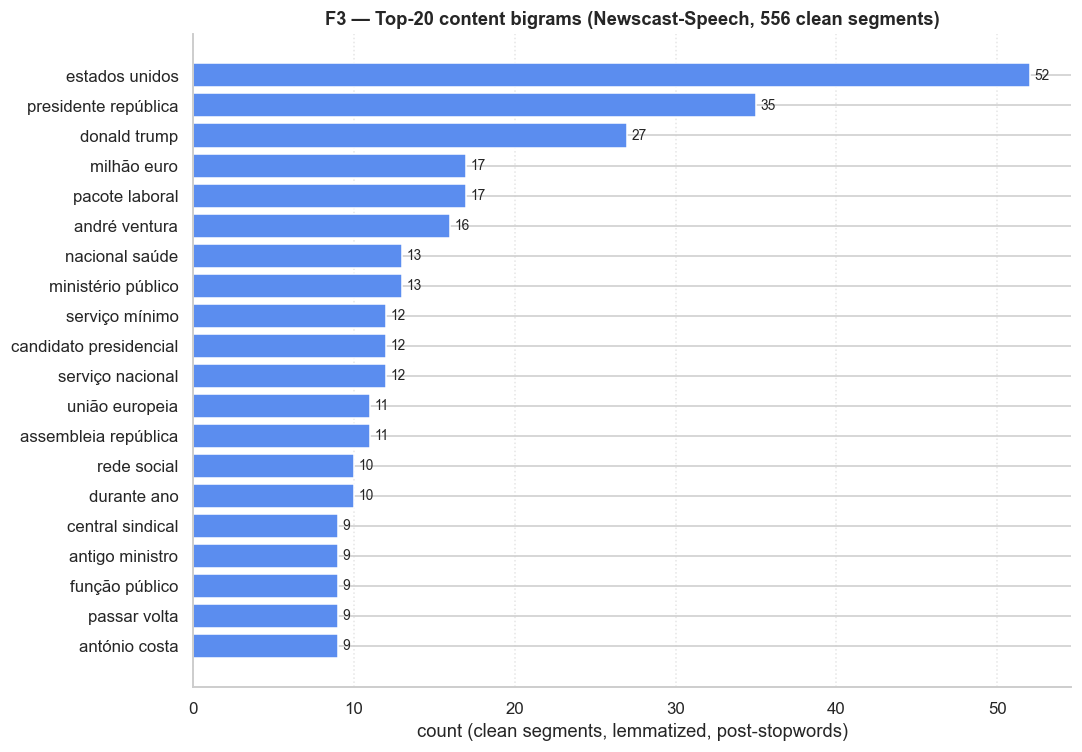

saved: <PROJECT_ROOT>/artifacts/figures/f3_linguistic.png

per-channel linguistic summary (medians, length-robust):
         segments  total_content_tokens  median_n_tokens  median_n_sentences  median_TTR
channel                                                                                 
RTP           161                  6955             33.0                 5.0       0.590
TVI           385                 16613             34.0                 6.0       0.595

vocabulary (content lemmas):
  total unique     : 7,363
  RTP only         : 1,411
  TVI only         : 4,465
  shared           : 1,487
  Jaccard(RTP,TVI) : 0.202


In [24]:
_top20 = top_bigrams[:20]
_labels = [" ".join(bg) for bg, _ in _top20][::-1]   # reverse so largest is at top
_counts = [c for _, c in _top20][::-1]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(_labels, _counts, color="#5b8def", edgecolor="white")
ax.set_xlabel("count (clean segments, lemmatized, post-stopwords)")
ax.set_title("F3 - Top-20 content bigrams (Newscast-Speech, 556 clean segments)")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
ax.grid(axis="x", linestyle=":", alpha=0.5)
fig.tight_layout()
_fig_path = save_fig(fig, "f3_linguistic")
plt.show()
print(f"saved: {_fig_path}")

# Per-channel linguistic summary
_chan_summary = (
    seg_tokens_df.groupby("channel")
    .agg(segments=("n_tokens", "size"),
         total_content_tokens=("n_tokens", "sum"),
         median_n_tokens=("n_tokens", "median"),
         median_n_sentences=("n_sentences", "median"),
         median_TTR=("type_token_ratio", "median"))
    .round(3)
)
print("\nper-channel linguistic summary (medians, length-robust):")
print(_chan_summary.to_string())

# Vocabulary stats
_vocab_overall = set(_all_tokens_flat)
_vocab_per_chan = {
    c: set(t for toks in seg_tokens_df.loc[seg_tokens_df["channel"] == c, "tokens"] for t in toks)
    for c in ("RTP", "TVI")
}
_shared = _vocab_per_chan["RTP"] & _vocab_per_chan["TVI"]
print(f"\nvocabulary (content lemmas):")
print(f"  total unique     : {len(_vocab_overall):,}")
print(f"  RTP only         : {len(_vocab_per_chan['RTP'] - _vocab_per_chan['TVI']):,}")
print(f"  TVI only         : {len(_vocab_per_chan['TVI'] - _vocab_per_chan['RTP']):,}")
print(f"  shared           : {len(_shared):,}")
print(f"  Jaccard(RTP,TVI) : {len(_shared) / len(_vocab_per_chan['RTP'] | _vocab_per_chan['TVI']):.3f}")

## 5. Candidate and party mentions

Which candidates and parties does each channel cover, and on which days?
For each of the eight candidates we match full-name anchors (including common Whisper transcription
variants) and bare surnames. A surname only counts if a full-name anchor for that candidate
appeared earlier in the same file, to avoid false matches on common words.


In [25]:
cp_df = pd.read_pickle(DATA_DIR / "candidate_party.pkl")
print("candidate_party.pkl:")
print(cp_df.to_string(index=False))

def fold(s: str) -> str:
    """ASCII-fold + lowercase. 'André' -> 'andre', 'Luís' -> 'luis'."""
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return s.lower()

CANDIDATES = {
    "Gouveia_Melo": {
        "display": "Henrique Gouveia e Melo",
        "anchors": [
            r"\bgouveia\s+e?\s*melo\b",            # canonical: Gouveia (e) Melo
            r"\bhenrique\s+gouveia\b",
            r"\balmirante\s+gouveia\b",
            r"\bgovimelo\b",                       # Whisper: Govimelo
            r"\bgov\.?\s*m\.?\s*l\b",              # Whisper: Gov.ML, GovML, Gov ML, Gov.M.L.
            r"\bgov\.?\s*melo\b",                  # Whisper: Gov.Melo, GovMelo
            r"\bcovamel\b",                        # Whisper: Covamel (within "Henrique Covamel")
            r"\bgovei\s+e?\s*mel\b",               # Whisper: govei e mel / govei mel
        ],
        "surnames": [
            r"\bgouveia\b",                        # alone, anchored only
        ],
    },
    "Marques_Mendes": {
        "display": "Luís Marques Mendes",
        "anchors": [
            r"\bmarques\s+mendes\b",               # canonical
            r"\bmarques\s+menos\b",                # Whisper: "menos" instead of Mendes
            r"\bluis\s+marques\s+mendes\b",
            r"\bluis\s+marques\b",
            r"\bmarx[\s\-]+mendes\b",              # Whisper: Marx-Mendes
            r"\bmarcos\s+mendes\b",                # Whisper: Marcos Mendes
        ],
        "surnames": [
            r"\bmendes\b",                         # alone, anchored only
        ],
    },
    "Seguro": {
        "display": "António José Seguro",
        "anchors": [
            r"\bantonio\s+jose\s+seguro\b",
            r"\bantonio\s+seguro\b",
            r"\bjose\s+seguro\b",
            r"\bantonio\s+ge\s+seguro\b",          # Whisper: António Gé seguro
            r"\bantoni[oa]s?\s+(e\s+|de\s+)?seguro\b",  # antónios e/de seguro
            r"\bantonis\s+ge\s+seguro\b",          # Antonis Gé seguro
        ],
        "surnames": [
            r"\bseguro\b",
        ],
    },
    "Ventura": {
        "display": "André Ventura",
        "anchors": [
            r"\bandre\s+ventura\b",
        ],
        "surnames": [
            r"\bventura\b",
        ],
    },
    "Cotrim_Figueiredo": {
        "display": "João Cotrim de Figueiredo",
        "anchors": [
            r"\bcotrim\s*(de\s+)?figueiredo\b",        # Cotrim (de) Figueiredo
            r"\bcotrinh[oa]\s*(de\s+)?figueiredo\b",   # Cotrinho/Cotrinha de Figueiredo
            r"\bjoao\s+cotrim\w*\b",                   # João Cotrim*
            r"\bjoao\s+cotrinh[oa]\b",
            r"\bcotrindo\s+figarei\b",                 # extreme Whisper: Cotrindo figarei
        ],
        "surnames": [
            r"\bcotrim\w*\b",                          # Cotrim, Cotrima
            r"\bcotrinh[oa]\b",                        # Cotrinho/Cotrinha alone
            # 'figueiredo' alone is too ambiguous
        ],
    },
    "Filipe": {
        "display": "António Filipe",
        "anchors": [
            r"\bantonio\s+filipe?\b",                  # António Filipe / Filip
            r"\bantonio\s+flipp?e?s?\b",               # Whisper: António Flipp / Flip / Flippe / Flippes
        ],
        "surnames": [
            r"\bfilipe?\b",                            # Filipe / Filip
            r"\bflipp?e?s?\b",                         # Flipp / Flip / Flippe / Flippes
        ],
    },
    "Martins": {
        "display": "Catarina Martins",
        "anchors": [
            r"\bcatarina\s+martins\b",
            r"\bcatarin\s+martins\b",                  # Whisper: Catarin
            r"\bcatrina\s+martins\b",                  # Whisper: Catrina
        ],
        "surnames": [
            r"\bmartins\b",
        ],
    },
    "Pinto": {
        "display": "Jorge Pinto",
        "anchors": [
            r"\bjorge\s+pinto\b",
            r"\bfelipe\s+pinto\b",                     # Whisper mangle for Jorge
        ],
        "surnames": [
            r"\bpinto\b",
        ],
    },
}

assert set(CANDIDATES.keys()) == set(cp_df["Candidate"]), (
    f"candidate keys mismatch: {set(CANDIDATES.keys()) ^ set(cp_df['Candidate'])}"
)

# Candidate -> party from the pkl (authoritative).
CANDIDATE_PARTY = dict(zip(cp_df["Candidate"], cp_df["Party"]))

# Party patterns. Acronyms that collide with common Portuguese words
# (BE, IL, L, "livre") are deliberately matched only via their full form.
PARTIES = {
    "PSD": [
        r"\bpsd\b",
        r"\bpartido\s+social[\s\-]*democrata\b",
        r"\bsocial[\s\-]*democratas?\b",
    ],
    "CDS": [
        r"\bcds\b",
        r"\bcds[\s\-]*pp\b",
        r"\bcentro\s+democratico\s+social\b",
    ],
    "PS": [
        r"\bps\b",                                     # 2-letter acronym, kept; will inspect noise
        r"\bpartido\s+socialista\b",
        r"\bsocialistas?\b",
    ],
    "CH": [
        r"\bchega\b",                                  # noun, but distinctive in this corpus
        r"\bpartido\s+chega\b",
    ],
    "IL": [
        r"\biniciativa\s+liberal\b",
    ],
    "CDU": [
        r"\bcdu\b",
        r"\bcoligacao\s+democratica\s+unitaria\b",
    ],
    "PCP": [
        r"\bpcp\b",
        r"\bpartido\s+comunista\b",
        r"\bcomunistas?\b",
    ],
    "BE": [
        r"\bbloco\s+de?\s+esquerda\b",
    ],
    "L": [
        r"\bpartido\s+livre\b",
    ],
    "PAN": [
        r"\bpan\b",
        r"\bpessoas\s+animais\s+natureza\b",
    ],
}

def _compile_patterns(pattern_dict_or_list):
    """Compile a {key: [pat,...]} dict or a list of raw patterns."""
    if isinstance(pattern_dict_or_list, list):
        return [re.compile(p) for p in pattern_dict_or_list]
    return {k: [re.compile(p) for p in v] for k, v in pattern_dict_or_list.items()}

matcher = {
    "candidates": {
        cid: {
            "display": v["display"],
            "anchors": _compile_patterns(v["anchors"]),
            "surnames": _compile_patterns(v["surnames"]),
        }
        for cid, v in CANDIDATES.items()
    },
    "parties": _compile_patterns(PARTIES),
}

_n_cand_pat = sum(len(c["anchors"]) + len(c["surnames"])
                  for c in matcher["candidates"].values())
_n_party_pat = sum(len(v) for v in matcher["parties"].values())
print(f"\ncompiled {_n_cand_pat} candidate patterns "
      f"({len(CANDIDATES)} candidates) "
      f"and {_n_party_pat} party patterns ({len(PARTIES)} parties).")

candidate_party.pkl:
        Candidate       Party
     Gouveia_Melo Independent
   Marques_Mendes     PSD+CDS
           Seguro          PS
          Ventura          CH
Cotrim_Figueiredo          IL
           Filipe         CDU
          Martins          BE
            Pinto           L

compiled 43 candidate patterns (8 candidates) and 21 party patterns (10 parties).


In [26]:
def find_mentions(text: str, matcher: dict, anchored: set) -> list[dict]:
    """Find candidate and party mentions in one segment.

    Surname-only hits count only if a full-name anchor for that candidate
    already appeared earlier in the same source file (`anchored` is updated
    in place).
    """
    folded = fold(text)
    out: list[dict] = []

    # 1. Parties - always count every match.
    for party_id, patterns in matcher["parties"].items():
        for pat in patterns:
            for m in pat.finditer(folded):
                out.append({
                    "entity_type": "party",
                    "entity_id": party_id,
                    "mention_type": "party",
                    "span_start": m.start(),
                    "span_end": m.end(),
                })

    # 2. Candidates - anchors first. Record their spans so we can suppress
    #    overlapping surname matches (avoid double-counting).
    full_spans_by_cand: dict[str, list[tuple[int, int]]] = {}
    for cand_id, cand in matcher["candidates"].items():
        spans = []
        for pat in cand["anchors"]:
            for m in pat.finditer(folded):
                spans.append((m.start(), m.end()))
                out.append({
                    "entity_type": "candidate",
                    "entity_id": cand_id,
                    "mention_type": "full",
                    "span_start": m.start(),
                    "span_end": m.end(),
                })
        if spans:
            anchored.add(cand_id)
        full_spans_by_cand[cand_id] = spans

    # 3. Candidate surnames - only count if anchored in this video AND
    #    the match span is not contained in a full-form match.
    for cand_id in list(anchored):
        cand = matcher["candidates"].get(cand_id)
        if cand is None:
            continue
        full_spans = full_spans_by_cand.get(cand_id, [])
        for pat in cand["surnames"]:
            for m in pat.finditer(folded):
                if any(fs <= m.start() and m.end() <= fe for fs, fe in full_spans):
                    continue
                out.append({
                    "entity_type": "candidate",
                    "entity_id": cand_id,
                    "mention_type": "surname",
                    "span_start": m.start(),
                    "span_end": m.end(),
                })

    return out

# (segment_idx) order so the anchored set grows correctly within each video.
clean = (
    speech_meta.loc[speech_meta["is_clean"]]
    .sort_values(["source_file", "segment_idx"])
    .reset_index(drop=True)
)

mention_rows: list[dict] = []
for source_file, vid in clean.groupby("source_file", sort=False):
    anchored: set[str] = set()
    for _, seg in vid.iterrows():
        for m in find_mentions(seg["transcript"], matcher, anchored):
            mention_rows.append({
                "channel":     seg["channel"],
                "date":        seg["date"],
                "date_raw":    seg["date_raw"],
                "segment_idx": int(seg["segment_idx"]),
                "source_file": source_file,
                **m,
            })

mentions_raw = pd.DataFrame(mention_rows)
print(f"raw mentions found: {len(mentions_raw)}")
print(f"breakdown by type: {dict(mentions_raw['mention_type'].value_counts())}")

# Aggregate to the spec'd long table:
# (channel, date, segment_idx, source_file, entity_type, entity_id, mention_type, count)
mentions_df = (
    mentions_raw
    .groupby(["channel", "date", "date_raw", "segment_idx", "source_file",
              "entity_type", "entity_id", "mention_type"], as_index=False)
    .size()
    .rename(columns={"size": "mention_count"})
)

mentions_df["party"] = np.where(
    mentions_df["entity_type"] == "candidate",
    mentions_df["entity_id"].map(CANDIDATE_PARTY),
    mentions_df["entity_id"],
)

MENTIONS_PATH = ARTIFACTS_DIR / "mentions.parquet"
mentions_df.to_parquet(MENTIONS_PATH, index=False)
print(f"\nwrote: {MENTIONS_PATH}  ({MENTIONS_PATH.stat().st_size / 1024:.1f} KiB)")
print(f"mentions_df shape: {mentions_df.shape}")
print(mentions_df.head(10).to_string(index=False))

raw mentions found: 159
breakdown by type: {'party': np.int64(77), 'full': np.int64(69), 'surname': np.int64(13)}

wrote: artifacts/mentions.parquet  (7.1 KiB)
mentions_df shape: (122, 10)
channel       date date_raw  segment_idx                      source_file entity_type      entity_id mention_type  mention_count   party
    RTP 2025-11-10   Nov_10            1 Telejornal_RTP_Nov_10_speech.pkl       party            CDS        party              1     CDS
    RTP 2025-11-10   Nov_10            7 Telejornal_RTP_Nov_10_speech.pkl   candidate        Martins         full              1      BE
    RTP 2025-11-10   Nov_10            8 Telejornal_RTP_Nov_10_speech.pkl       party             CH        party              1      CH
    RTP 2025-11-10   Nov_10            8 Telejornal_RTP_Nov_10_speech.pkl       party             PS        party              1      PS
    RTP 2025-11-20   Nov_20           11 Telejornal_RTP_Nov_20_speech.pkl       party             CH        party             

RTP candidate × date (mentions):
date               2025-11-10  2025-11-20  2025-12-02  2025-12-11  2025-12-18  2026-01-06  2026-01-11  2026-01-13
entity_id                                                                                                        
Ventura                     0           0           0           0           0           2           0          10
Filipe                      0           1           0           0           0           0           0           3
Seguro                      0           0           0           0           0           1           0          10
Marques_Mendes              0           1           0           0           0           0           0           5
Cotrim_Figueiredo           0           0           0           0           0           0           0           7
Gouveia_Melo                0           0           0           0           0           0           0           5
Martins                     1           1           0  

/tmp/claude-501/ipykernel_66463/3676654418.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


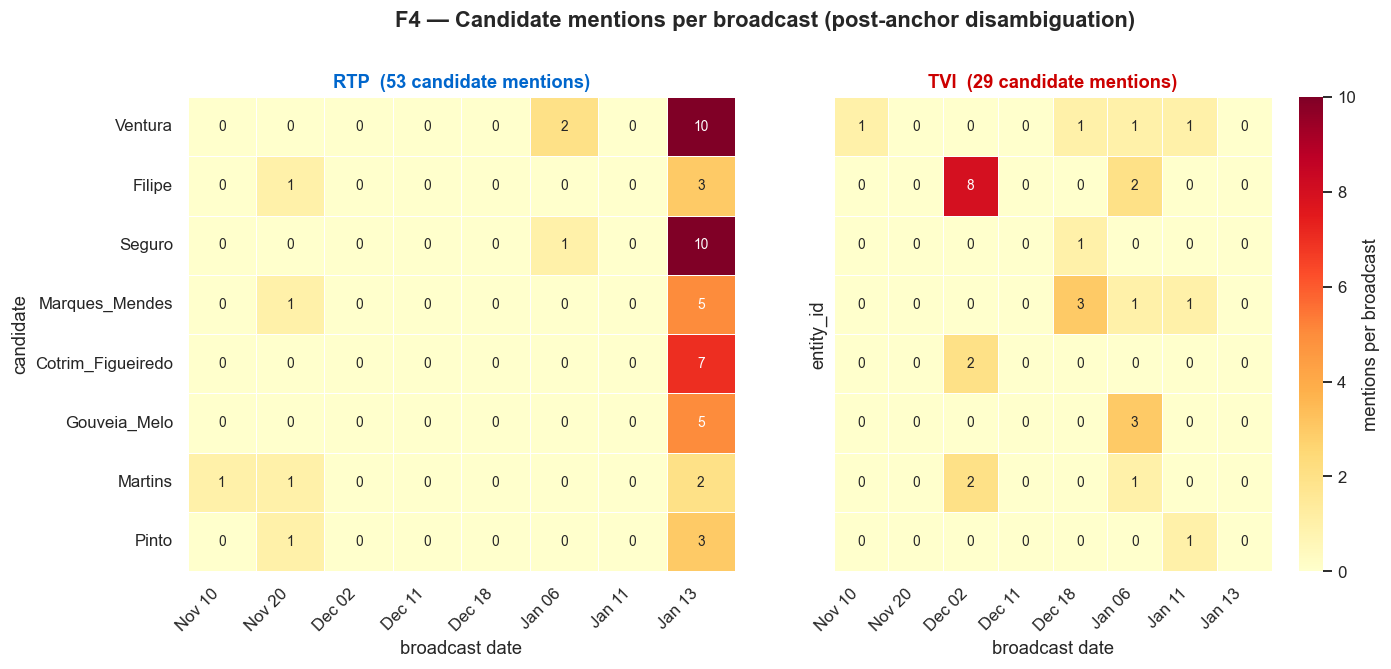

saved: <PROJECT_ROOT>/artifacts/figures/f4_mentions_heatmap.png

 SECTION 5 — TOP-3 SUMMARY

Top-3 candidates (corpus-wide, anchored disambiguation):
  Ventura                André Ventura                    (CH         ) — 16 mentions
  Filipe                 António Filipe                   (CDU        ) — 14 mentions
  Seguro                 António José Seguro              (PS         ) — 12 mentions

Full candidate breakdown (full vs surname):
mention_type       full  surname  total
entity_id                              
Ventura              16        0     16
Filipe               11        3     14
Seguro                4        8     12
Marques_Mendes       11        0     11
Cotrim_Figueiredo     7        2      9
Gouveia_Melo          8        0      8
Martins               7        0      7
Pinto                 5        0      5

Top-3 parties (corpus-wide):
  PS    — 30 mentions
  CH    — 22 mentions
  PSD   — 15 mentions



Candidate mentions per channel:
channel            RTP  TVI
entity_id                  
Ventura             12    4
Filipe               4   10
Seguro              11    1
Marques_Mendes       6    5
Cotrim_Figueiredo    7    2
Gouveia_Melo         5    3
Martins              4    3
Pinto                4    1


In [27]:
# Per-candidate totals (sum across all segments, all dates, both channels).
cand_totals = (
    mentions_df.loc[mentions_df["entity_type"] == "candidate"]
    .groupby("entity_id")["mention_count"].sum()
    .sort_values(ascending=False)
)
party_totals = (
    mentions_df.loc[mentions_df["entity_type"] == "party"]
    .groupby("entity_id")["mention_count"].sum()
    .sort_values(ascending=False)
)

# Also break candidate totals by mention_type to expose anchor vs surname share.
cand_breakdown = (
    mentions_df.loc[mentions_df["entity_type"] == "candidate"]
    .groupby(["entity_id", "mention_type"])["mention_count"].sum()
    .unstack(fill_value=0)
    .assign(total=lambda d: d.sum(axis=1))
    .sort_values("total", ascending=False)
)

# Build the (candidate x date) matrix per channel for Figure F4.
# Rows: candidates ordered by overall mention volume (most-mentioned at top).
cand_order = cand_totals.index.tolist()
# Columns: union of dates from both channels, sorted chronologically.
all_dates = sorted(clean["date"].unique())
date_labels = [pd.Timestamp(d).strftime("%b %d") for d in all_dates]

def _matrix_for_channel(chan: str) -> pd.DataFrame:
    sub = mentions_df[(mentions_df["channel"] == chan)
                      & (mentions_df["entity_type"] == "candidate")]
    pivot = (
        sub.groupby(["entity_id", "date"])["mention_count"].sum()
        .unstack(fill_value=0)
    )
    # Fill missing dates / candidates so the layout is consistent across panels.
    pivot = pivot.reindex(index=cand_order, columns=all_dates, fill_value=0)
    return pivot

mat_rtp = _matrix_for_channel("RTP")
mat_tvi = _matrix_for_channel("TVI")
print("RTP candidate × date (mentions):")
print(mat_rtp.to_string())
print("\nTVI candidate × date (mentions):")
print(mat_tvi.to_string())

# Two-panel heatmap (one per channel), shared candidate-row order, shared colormap scale.
_vmax = max(mat_rtp.values.max(), mat_tvi.values.max(), 1)

fig, axes = plt.subplots(
    1, 2, figsize=(14, 5.6),
    gridspec_kw={"width_ratios": [1, 1], "wspace": 0.18},
    sharey=True,
)

for ax, mat, chan in zip(axes, (mat_rtp, mat_tvi), ("RTP", "TVI")):
    sns.heatmap(
        mat, ax=ax,
        cmap="YlOrRd", vmin=0, vmax=_vmax,
        annot=True, fmt="d",
        annot_kws={"size": 9},
        cbar=(chan == "TVI"),  # one colorbar, on the right panel
        cbar_kws={"label": "mentions per broadcast"} if chan == "TVI" else None,
        linewidths=0.6, linecolor="white",
        xticklabels=date_labels,
    )
    ax.set_title(f"{chan}  ({mat.values.sum():,} candidate mentions)",
                 color=CHANNEL_COLORS[chan], fontweight="bold")
    ax.set_xlabel("broadcast date")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

axes[0].set_ylabel("candidate")
fig.suptitle("F4 - Candidate mentions per broadcast (post-anchor disambiguation)",
             fontweight="bold", y=1.02)
fig.tight_layout()
_fig_path = save_fig(fig, "f4_mentions_heatmap")
plt.show()
print(f"saved: {_fig_path}")

# Top-3 prints + per-channel slices for the slide.
print("\n" + "=" * 64)
print(" SECTION 5 - TOP-3 SUMMARY")
print("=" * 64)
print("\nTop-3 candidates (corpus-wide, anchored disambiguation):")
for cid, n in cand_totals.head(3).items():
    party = CANDIDATE_PARTY[cid]
    print(f"  {cid:<22s} {CANDIDATES[cid]['display']:<32s} ({party:<11s}) - {n} mentions")

print("\nFull candidate breakdown (full vs surname):")
print(cand_breakdown.to_string())

print("\nTop-3 parties (corpus-wide):")
for pid, n in party_totals.head(3).items():
    print(f"  {pid:<5s} - {n} mentions")

# Per-channel candidate totals - the editorial signal.
_per_chan_cand = (
    mentions_df.loc[mentions_df["entity_type"] == "candidate"]
    .groupby(["entity_id", "channel"])["mention_count"].sum()
    .unstack(fill_value=0)
    .reindex(cand_order)
)
print("\nCandidate mentions per channel:")
print(_per_chan_cand.to_string())
print("=" * 64)

## 6. Embedding geometry

L2-normalize the EuroLLM embeddings, reduce to 50 PCA components, project to 2D with UMAP,
and cluster the PCA space with KMeans (k chosen by silhouette score for k = 3..10).
Each cluster is labelled by its top differential TF-IDF terms.
Results saved to `artifacts/segment_clusters.parquet`.


In [28]:
import umap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer

# Same subset used in Sections 3-5 and Section 4.1.
geom_subset = (
    speech_meta.loc[speech_meta["is_clean"] & ~speech_meta["is_partial_capture"]]
    .reset_index()  # row_idx is the original speech_meta index, used to slice speech_emb
    .rename(columns={"index": "row_idx"})
)
print(f"geometry subset: {len(geom_subset)} segments "
      f"(RTP={int((geom_subset['channel']=='RTP').sum())}, "
      f"TVI={int((geom_subset['channel']=='TVI').sum())})")

# Pull the corresponding embeddings.
emb_raw = speech_emb[geom_subset["row_idx"].to_numpy()].astype(np.float32)
print(f"emb_raw: {emb_raw.shape}, dtype={emb_raw.dtype}")

# 1. L2-normalise - cosine sim becomes a dot product.
emb_n = normalize(emb_raw, norm="l2", axis=1)

# 2. PCA-50 (denoising step before UMAP / KMeans).
pca = PCA(n_components=50, random_state=SEED)
emb_pca = pca.fit_transform(emb_n)
print(f"PCA-50 explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# 3. UMAP - canonical pipeline (PCA-50 -> 2D).
print("UMAP: PCA-50 → 2D (canonical)...")
reducer = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric="cosine", random_state=SEED,
)
emb_2d = reducer.fit_transform(emb_pca)

# 3b. Sanity check: UMAP on raw 4096-d (without PCA). Discarded after inspection.
print("UMAP: raw 4096-d → 2D (sanity check)...")
reducer_raw = umap.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric="cosine", random_state=SEED,
)
emb_2d_raw = reducer_raw.fit_transform(emb_n)
from scipy.spatial.distance import pdist
_dist_pca = pdist(emb_2d)
_dist_raw = pdist(emb_2d_raw)
_corr = float(np.corrcoef(_dist_pca, _dist_raw)[0, 1])
print(f"pairwise-distance correlation (PCA-pipeline vs raw): {_corr:.3f} "
      f"→ {'consistent' if _corr > 0.6 else 'divergent'}")

# 4. KMeans sweep on PCA-50 cosine space.
sil = {}
for k in range(3, 11):
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km_k.fit_predict(emb_pca)
    sil[k] = float(silhouette_score(emb_pca, labels_k, metric="cosine"))
print("\nKMeans silhouette by k (cosine, PCA-50 space):")
for k, s in sil.items():
    print(f"  k={k:>2d}  silhouette={s:.4f}")
best_k = max(sil, key=sil.get)
print(f"\nbest k = {best_k}  (silhouette={sil[best_k]:.4f})")

km = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_ids = km.fit_predict(emb_pca)
_sizes = pd.Series(cluster_ids).value_counts().sort_index().to_dict()
print(f"cluster sizes: {_sizes}")

# 5. Topic labels - top differential TF-IDF terms per cluster.
_tok_lookup = {
    (sf, si): toks for sf, si, toks in zip(
        seg_tokens_df["source_file"],
        seg_tokens_df["segment_idx"],
        seg_tokens_df["tokens"],
    )
}
_geom_keys = list(zip(geom_subset["source_file"], geom_subset["segment_idx"]))
docs = [" ".join(_tok_lookup[k]) for k in _geom_keys]

tfidf_c = TfidfVectorizer(token_pattern=r"\S+", min_df=3, sublinear_tf=True)
X_c = tfidf_c.fit_transform(docs)
vocab_c = tfidf_c.get_feature_names_out()
print(f"cluster TF-IDF: {X_c.shape[0]} segments × {X_c.shape[1]} terms")

cluster_topics: dict[int, list[tuple[str, float]]] = {}
for c in range(best_k):
    mask = (cluster_ids == c)
    if mask.sum() == 0:
        cluster_topics[c] = []
        continue
    in_mean = np.asarray(X_c[mask].mean(axis=0)).ravel()
    out_mean = np.asarray(X_c[~mask].mean(axis=0)).ravel()
    diff = in_mean - out_mean
    top_idx = np.argsort(diff)[::-1][:10]
    cluster_topics[c] = [(vocab_c[i], float(diff[i])) for i in top_idx]

print("\nCluster topic labels (top differential TF-IDF terms):")
for c in sorted(cluster_topics):
    n_c = int((cluster_ids == c).sum())
    rtp_n = int((cluster_ids == c)[geom_subset["channel"].to_numpy() == "RTP"].sum())
    tvi_n = n_c - rtp_n
    label = ", ".join(w for w, _ in cluster_topics[c][:6])
    print(f"  cluster {c}  n={n_c:>3d}  (RTP={rtp_n:>3d}, TVI={tvi_n:>3d})  → {label}")

# 6. Persist segment_clusters.parquet
seg_clusters_df = geom_subset[
    ["channel", "date", "date_raw", "segment_idx", "source_file", "row_idx"]
].copy()
seg_clusters_df["cluster_id"] = cluster_ids
seg_clusters_df["umap_x"] = emb_2d[:, 0]
seg_clusters_df["umap_y"] = emb_2d[:, 1]

CLUSTERS_PATH = ARTIFACTS_DIR / "segment_clusters.parquet"
seg_clusters_df.to_parquet(CLUSTERS_PATH, index=False)
print(f"\nwrote: {CLUSTERS_PATH}  ({CLUSTERS_PATH.stat().st_size / 1024:.1f} KiB)")
print(f"shape: {seg_clusters_df.shape}")

geometry subset: 546 segments (RTP=161, TVI=385)
emb_raw: (546, 4096), dtype=float32
PCA-50 explained variance: 76.7%
UMAP: PCA-50 → 2D (canonical)...


<PROJECT_ROOT>/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: raw 4096-d → 2D (sanity check)...


<PROJECT_ROOT>/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


pairwise-distance correlation (PCA-pipeline vs raw): 0.705 → consistent

KMeans silhouette by k (cosine, PCA-50 space):
  k= 3  silhouette=0.1694
  k= 4  silhouette=0.1597
  k= 5  silhouette=0.1462
  k= 6  silhouette=0.1365
  k= 7  silhouette=0.1419
  k= 8  silhouette=0.1313
  k= 9  silhouette=0.1266
  k=10  silhouette=0.1401

best k = 3  (silhouette=0.1694)
cluster sizes: {0: 159, 1: 247, 2: 140}


cluster TF-IDF: 546 segments × 1514 terms

Cluster topic labels (top differential TF-IDF terms):
  cluster 0  n=159  (RTP= 53, TVI=106)  → trump, donald, presidente, operação, venezuela, ucrania
  cluster 1  n=247  (RTP= 76, TVI=171)  → achar, querer, falar, gente, algum, perceber
  cluster 2  n=140  (RTP= 32, TVI=108)  → aumento, acesso, euro, portugal, registar, médico

wrote: artifacts/segment_clusters.parquet  (15.0 KiB)
shape: (546, 9)


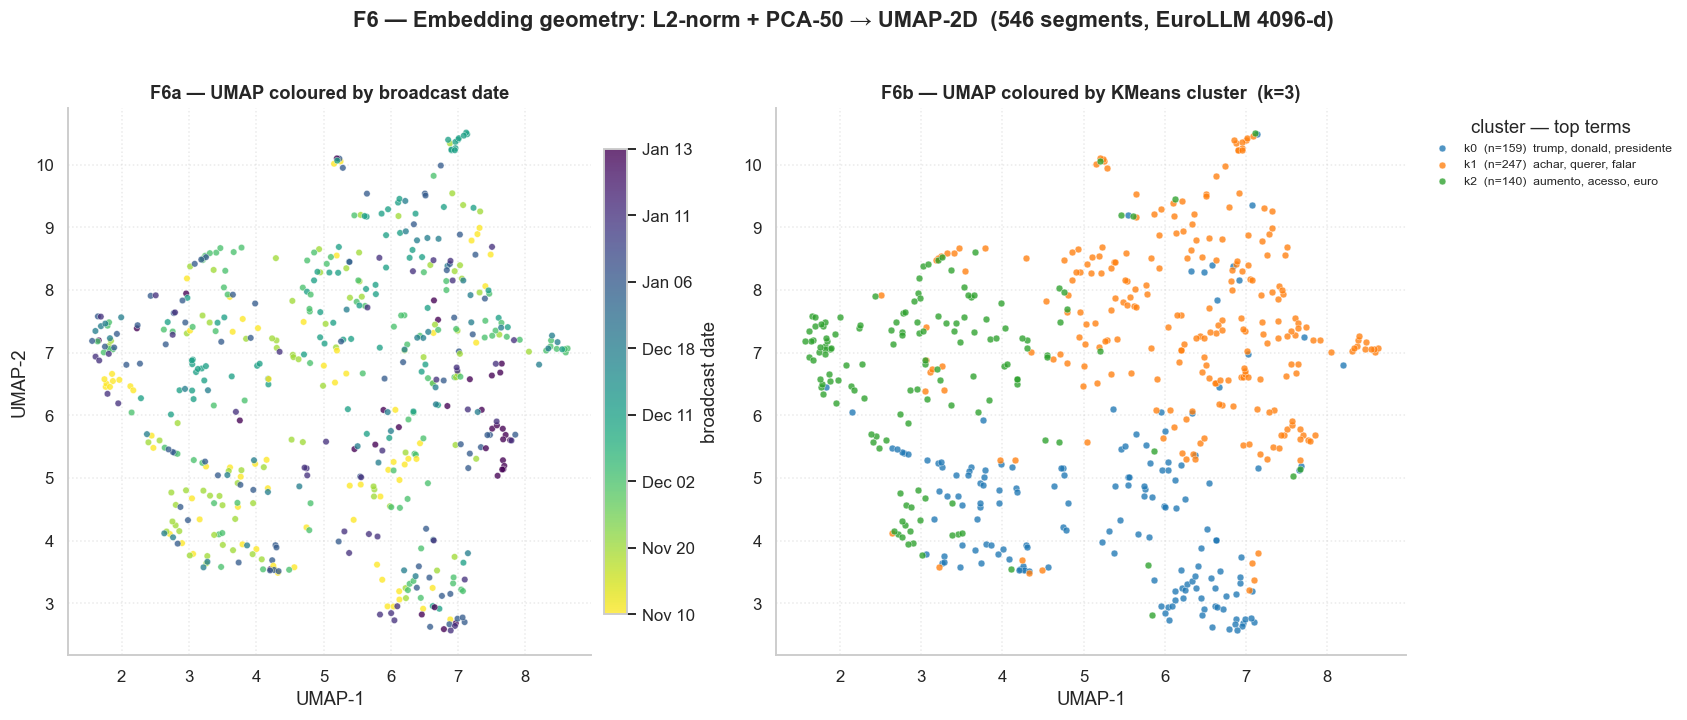

saved: <PROJECT_ROOT>/artifacts/figures/f6_umap.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.4))

# Panel A - coloured by date (sequential).
dates_unique = sorted(geom_subset["date"].unique())
date_to_idx = {d: i for i, d in enumerate(dates_unique)}
date_idx_arr = geom_subset["date"].map(date_to_idx).to_numpy()
sc_a = axes[0].scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=date_idx_arr, cmap="viridis_r",
    s=18, alpha=0.78, edgecolors="white", linewidth=0.3,
)
axes[0].set_title("F6a - UMAP coloured by broadcast date")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].grid(linestyle=":", alpha=0.4)
cb = fig.colorbar(sc_a, ax=axes[0], shrink=0.85, pad=0.02)
cb.set_ticks(range(len(dates_unique)))
cb.set_ticklabels([pd.Timestamp(d).strftime("%b %d") for d in dates_unique])
cb.set_label("broadcast date")

# Panel B - coloured by KMeans cluster, legend = top-3 terms per cluster.
palette = sns.color_palette("tab10", n_colors=best_k)
for c in range(best_k):
    mask = cluster_ids == c
    label_top = ", ".join(w for w, _ in cluster_topics[c][:3])
    axes[1].scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=[palette[c]], s=20, alpha=0.78,
        edgecolors="white", linewidth=0.3,
        label=f"k{c}  (n={int(mask.sum())})  {label_top}",
    )
axes[1].set_title(f"F6b - UMAP coloured by KMeans cluster  (k={best_k})")
axes[1].set_xlabel("UMAP-1")
axes[1].grid(linestyle=":", alpha=0.4)
axes[1].legend(
    bbox_to_anchor=(1.02, 1), loc="upper left",
    fontsize=8, frameon=False, title="cluster - top terms",
)

fig.suptitle(
    "F6 - Embedding geometry: L2-norm + PCA-50 → UMAP-2D  "
    f"({len(geom_subset)} segments, EuroLLM 4096-d)",
    fontweight="bold", y=1.02,
)
fig.tight_layout()
_fig_path = save_fig(fig, "f6_umap")
plt.show()
print(f"saved: {_fig_path}")

## 7. Per-broadcast topic mix

Using the KMeans cluster labels from Section 6, we collapse to one row per broadcast
to see each show's topic distribution across dates.


Per-broadcast topic mix (% of clean segments per cluster):
                      k0    k1    k2
channel date                        
RTP     2025-11-10  50.0  25.0  25.0
        2025-11-20  30.8  46.2  23.1
        2025-12-02  40.0  40.0  20.0
        2025-12-11  11.1  59.3  29.6
        2026-01-06  36.0  56.0   8.0
        2026-01-13  32.4  52.9  14.7
TVI     2025-11-10  38.0  28.0  34.0
        2025-11-20  32.8  32.8  34.4
        2025-12-02  21.3  56.0  22.7
        2025-12-11   3.6  70.9  25.5
        2025-12-18  31.2  52.1  16.7
        2026-01-06  34.6  26.9  38.5
        2026-01-11  36.4  38.6  25.0

clusters in legend order: ['trump donald presidente', 'achar querer falar', 'aumento acesso euro']


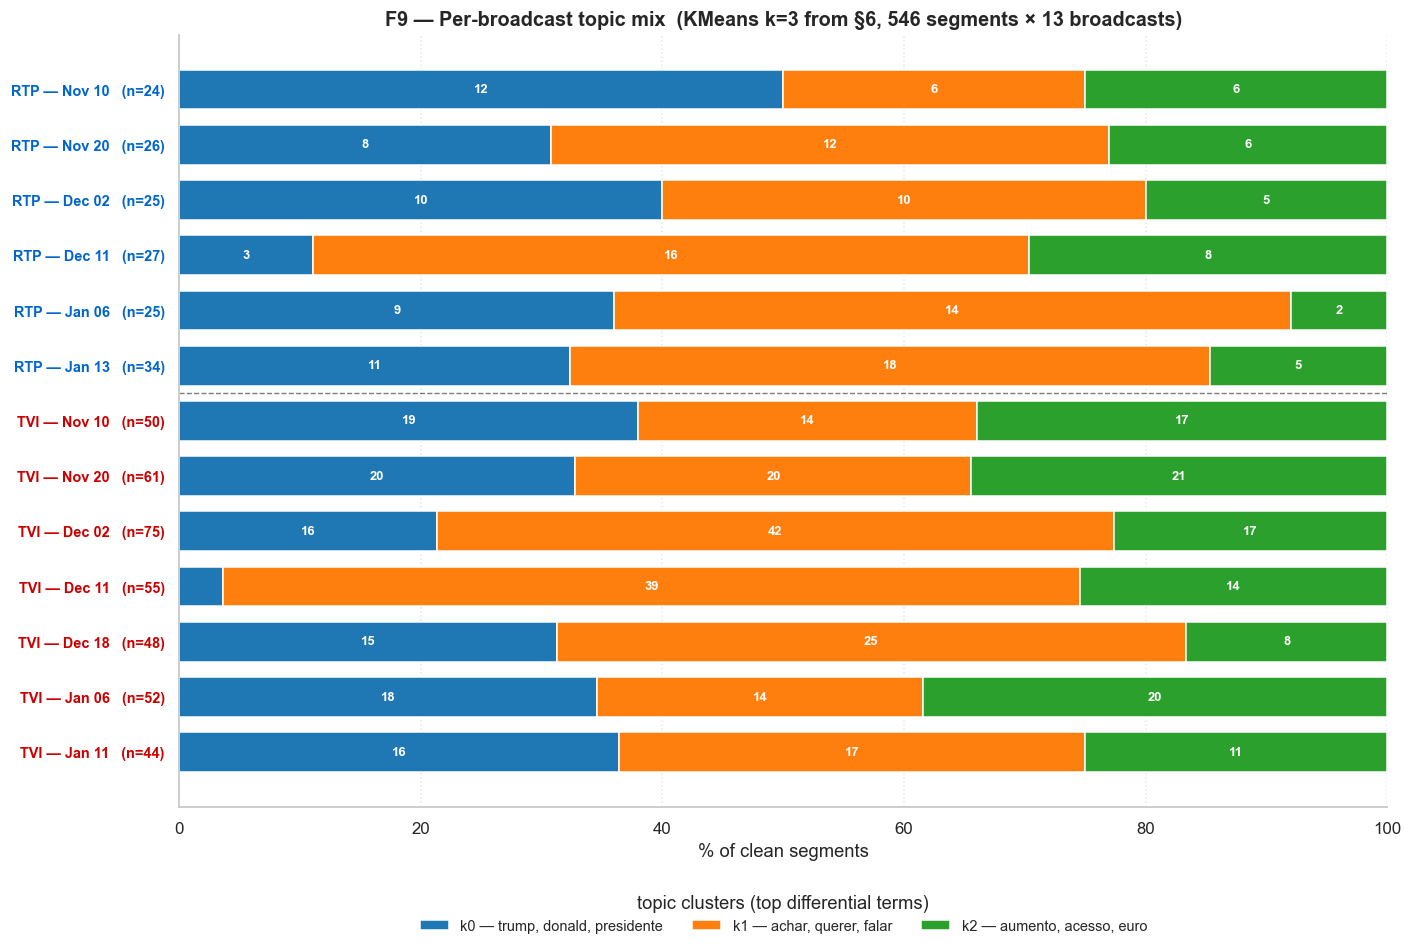

saved: <PROJECT_ROOT>/artifacts/figures/f9_per_broadcast_topic_mix.png

Per-channel mean topic mix (averaged across broadcasts):
           k0    k1    k2
channel                  
RTP      33.4  46.6  20.1
TVI      28.3  43.6  28.1


In [30]:
# Aggregate cluster shares per (channel, date) using seg_clusters_df (Section 6).
mix_counts = (
    seg_clusters_df.groupby(["channel", "date", "cluster_id"])
    .size().unstack(fill_value=0)
)
mix_counts.columns = [f"k{c}" for c in mix_counts.columns]
mix_pct = mix_counts.div(mix_counts.sum(axis=1), axis=0) * 100

# Order rows: RTP-first (chronological), then TVI (chronological). Same logic as F2.
mix_pct = (
    mix_pct.reset_index()
    .assign(_chan_rank=lambda d: d["channel"].map({"RTP": 0, "TVI": 1}))
    .sort_values(["_chan_rank", "date"])
    .drop(columns="_chan_rank")
    .set_index(["channel", "date"])
)
mix_counts = mix_counts.loc[mix_pct.index]

print("Per-broadcast topic mix (% of clean segments per cluster):")
print(mix_pct.round(1).to_string())
print(f"\nclusters in legend order: "
      f"{[' '.join(w for w,_ in cluster_topics[c][:3]) for c in range(best_k)]}")

# Build the row labels: "RTP - Nov 10  (n=24)"
row_labels = [
    f"{chan} - {pd.Timestamp(d).strftime('%b %d')}   (n={int(mix_counts.loc[(chan, d)].sum())})"
    for (chan, d) in mix_pct.index
]

# Cluster human-readable names for the legend.
cluster_short_label = {
    c: ", ".join(w for w, _ in cluster_topics[c][:3])
    for c in range(best_k)
}

# Stacked horizontal bars.
fig, ax = plt.subplots(figsize=(13, 0.55 * len(mix_pct) + 1.6))
palette = sns.color_palette("tab10", n_colors=best_k)

left = np.zeros(len(mix_pct))
y_pos = np.arange(len(mix_pct))
bar_h = 0.72
for ci, c in enumerate(range(best_k)):
    col = f"k{c}"
    vals = mix_pct[col].to_numpy()
    cnts = mix_counts[col].to_numpy()
    ax.barh(
        y_pos, vals, left=left, height=bar_h,
        color=palette[ci], edgecolor="white", linewidth=1.0,
        label=f"k{c} - {cluster_short_label[c]}",
    )
    # Annotate each segment with its count if it's wide enough.
    for yi, (v, n) in enumerate(zip(vals, cnts)):
        if v >= 8:
            ax.text(
                left[yi] + v / 2, yi, f"{n}",
                ha="center", va="center", fontsize=8.5,
                color="white", fontweight="bold",
            )
    left += vals

n_rtp = sum(1 for chan, _ in mix_pct.index if chan == "RTP")
if 0 < n_rtp < len(mix_pct):
    ax.axhline(n_rtp - 0.5, color="#444", linestyle="--", linewidth=0.9, alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(row_labels, fontsize=9.5)
for tick_label, (chan, _d) in zip(ax.get_yticklabels(), mix_pct.index):
    tick_label.set_color(CHANNEL_COLORS[chan])
    tick_label.set_fontweight("bold")
ax.invert_yaxis()  # earliest broadcast at top
ax.set_xlim(0, 100)
ax.set_xlabel("% of clean segments")
ax.set_title(
    f"F9 - Per-broadcast topic mix  "
    f"(KMeans k={best_k} from §6, {len(seg_clusters_df)} segments × {len(mix_pct)} broadcasts)",
    fontsize=13, fontweight="bold",
)
ax.grid(axis="x", linestyle=":", alpha=0.5)
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, -0.18 if len(mix_pct) >= 10 else -0.25),
    ncol=best_k, frameon=False, fontsize=9.5,
    title="topic clusters (top differential terms)",
)
fig.tight_layout()
_fig_path = save_fig(fig, "f9_per_broadcast_topic_mix")
plt.show()
print(f"saved: {_fig_path}")

print("\nPer-channel mean topic mix (averaged across broadcasts):")
chan_mean_mix = mix_pct.reset_index().groupby("channel")[
    [f"k{c}" for c in range(best_k)]
].mean().round(1)
print(chan_mean_mix.to_string())

## 8. Structural symmetry between channels

Sections 4, 5, and 6 show that RTP and TVI cover different stories.
Here we check whether their speech structure is similar: segment duration, content tokens,
sentence count, and characters per second. We use a Mann-Whitney U test because
the distributions are right-skewed.


metrics frame: (556, 8), channels: {'TVI': 385, 'RTP': 171}

Mann-Whitney U test  (RTP vs TVI, two-sided):
       metric  RTP_n  TVI_n  RTP_median  TVI_median  RTP_mean  TVI_mean       U  p_value  significant_at_0.05
     duration    171    385     29.3460     32.0460   40.7976   40.5906 30589.0   0.1829                False
     n_tokens    161    385     33.0000     34.0000   43.1988   43.1506 29961.0   0.5395                False
  n_sentences    161    385      5.0000      6.0000    5.7453    6.8078 26802.5   0.0119                 True
chars_per_sec    171    385     15.7867     15.6686   15.9240   15.8383 33340.0   0.8092                False

Interpretation: high p (>0.05) ⇒ NO significant difference between channels at the structural level.


/tmp/claude-501/ipykernel_66463/2460361436.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/claude-501/ipykernel_66463/2460361436.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/claude-501/ipykernel_66463/2460361436.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/claude-501/ipykernel_66463/2460361436.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp

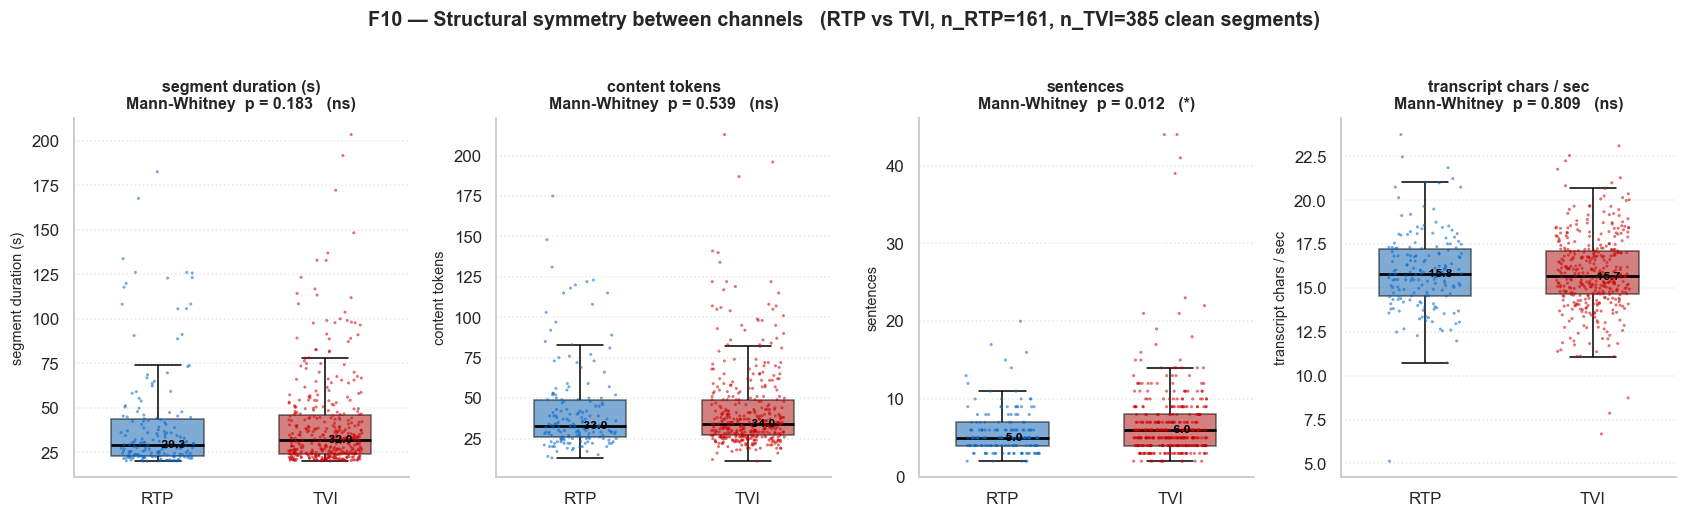

saved: <PROJECT_ROOT>/artifacts/figures/f10_structural_symmetry.png


In [31]:
from scipy.stats import mannwhitneyu

# Build a per-segment metrics frame on the SAME 546-segment subset used in 3-6.
# Pull n_tokens / n_sentences from seg_tokens_df (already aligned by source_file+segment_idx).
metrics = (
    clean[["source_file", "segment_idx", "channel", "duration",
           "transcript", "chars_per_sec"]]
    .merge(
        seg_tokens_df[["source_file", "segment_idx", "n_tokens", "n_sentences"]],
        on=["source_file", "segment_idx"], how="left",
    )
)
if metrics["chars_per_sec"].isna().any():
    _missing = metrics["chars_per_sec"].isna()
    metrics.loc[_missing, "chars_per_sec"] = (
        metrics.loc[_missing, "transcript"].str.len() /
        metrics.loc[_missing, "duration"]
    )
print(f"metrics frame: {metrics.shape}, channels: "
      f"{metrics['channel'].value_counts().to_dict()}")

panels = [
    ("duration",      "segment duration (s)",  "linear"),
    ("n_tokens",      "content tokens",        "linear"),
    ("n_sentences",   "sentences",             "linear"),
    ("chars_per_sec", "transcript chars / sec", "linear"),
]

mwu_rows = []
for col, label, _ in panels:
    rtp = metrics.loc[metrics["channel"] == "RTP", col].dropna().to_numpy()
    tvi = metrics.loc[metrics["channel"] == "TVI", col].dropna().to_numpy()
    u, p = mannwhitneyu(rtp, tvi, alternative="two-sided")
    mwu_rows.append({
        "metric":      col,
        "RTP_n":       len(rtp),
        "TVI_n":       len(tvi),
        "RTP_median":  float(np.median(rtp)),
        "TVI_median":  float(np.median(tvi)),
        "RTP_mean":    float(np.mean(rtp)),
        "TVI_mean":    float(np.mean(tvi)),
        "U":           float(u),
        "p_value":     float(p),
        "significant_at_0.05": bool(p < 0.05),
    })
mwu_df = pd.DataFrame(mwu_rows)
print("\nMann-Whitney U test  (RTP vs TVI, two-sided):")
print(mwu_df.round(4).to_string(index=False))
print("\nInterpretation: high p (>0.05) ⇒ NO significant difference between channels"
      " at the structural level.")

# Plot: 1 row x 4 panels with violinplot + overlaid stripplot for visible distribution.
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.6))
chan_order = ["RTP", "TVI"]
chan_pal = [CHANNEL_COLORS[c] for c in chan_order]

for ax, (col, label, _yscale) in zip(axes, panels):
    sns.boxplot(
        data=metrics, x="channel", y=col,
        order=chan_order, palette=chan_pal,
        ax=ax, width=0.55, fliersize=0,
        boxprops={"alpha": 0.55, "edgecolor": "black"},
        medianprops={"color": "black", "linewidth": 1.8},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
    )
    sns.stripplot(
        data=metrics, x="channel", y=col,
        order=chan_order, palette=chan_pal,
        ax=ax, size=2.0, alpha=0.55, jitter=0.22,
    )
    p_val = mwu_df.loc[mwu_df["metric"] == col, "p_value"].iloc[0]
    rtp_med = mwu_df.loc[mwu_df["metric"] == col, "RTP_median"].iloc[0]
    tvi_med = mwu_df.loc[mwu_df["metric"] == col, "TVI_median"].iloc[0]
    sig_marker = "ns" if p_val >= 0.05 else "*"
    ax.set_title(
        f"{label}\nMann-Whitney  p = {p_val:.3f}   ({sig_marker})",
        fontsize=10.5, fontweight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=9.5)
    ax.grid(axis="y", linestyle=":", alpha=0.45)
    # Median annotations
    ax.text(0, rtp_med, f" {rtp_med:.1f}", color="black", va="center",
            fontsize=8, fontweight="bold")
    ax.text(1, tvi_med, f" {tvi_med:.1f}", color="black", va="center",
            fontsize=8, fontweight="bold")

fig.suptitle(
    "F10 - Structural symmetry between channels   "
    "(RTP vs TVI, n_RTP=161, n_TVI=385 clean segments)",
    fontsize=13, fontweight="bold", y=1.02,
)
fig.tight_layout()
_fig_path = save_fig(fig, "f10_structural_symmetry")
plt.show()
print(f"saved: {_fig_path}")

## 9. Foreign vs domestic news share

The bigram list is dominated by international topics (estados unidos, donald trump, uniao europeia).
Here we measure the share of segments mentioning a foreign country, leader, conflict, or organisation
per broadcast, and plot it as a line per channel over time.


foreign-news share per broadcast:
channel   date  segments  foreign  foreign_%
    RTP Nov 10        24        3       12.5
    RTP Nov 20        26        4       15.4
    RTP Dec 02        25        8       32.0
    RTP Dec 11        27        3       11.1
    RTP Jan 06        25        5       20.0
    RTP Jan 13        34        5       14.7
    TVI Nov 10        50        9       18.0
    TVI Nov 20        61       12       19.7
    TVI Dec 02        75       15       20.0
    TVI Dec 11        55        5        9.1
    TVI Dec 18        48        8       16.7
    TVI Jan 06        52        9       17.3
    TVI Jan 11        44       14       31.8


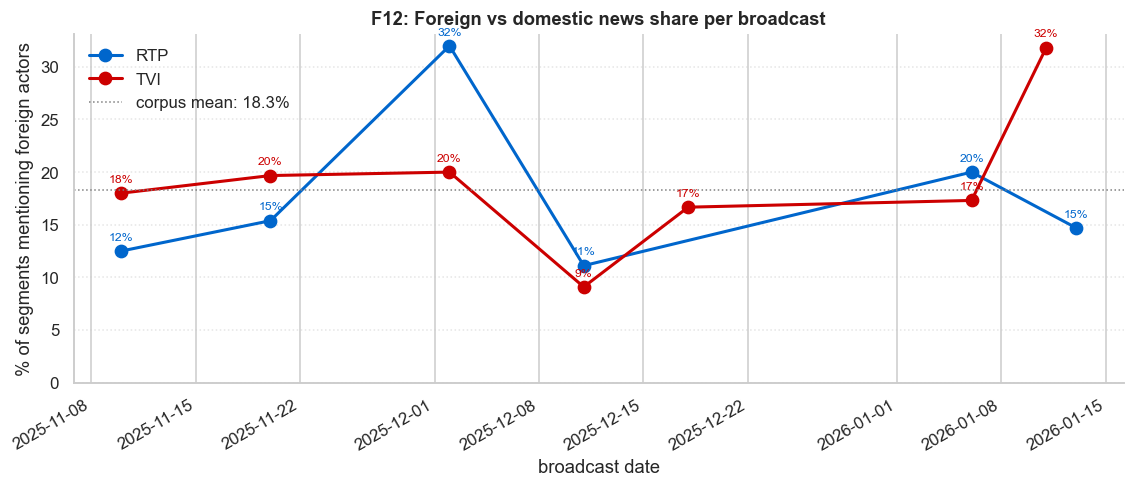

saved: <PROJECT_ROOT>/artifacts/figures/f12_foreign_share.png

Top foreign markers (corpus):
  trump                  54
  estados unidos         52
  venezuela              39
  ucrania                23
  frança                 15
  putin                  15
  rússia                 14
  união europeia         12
  russia                 9
  espanha                6
  nato                   5
  china                  4

per-channel foreign share:
         segments  foreign  foreign_pct
channel                                
RTP           161       28         17.4
TVI           385       72         18.7


In [32]:
# Curated marker list. Whole-word matches only, case-insensitive.
# Three groups: states / places, leaders, conflicts and orgs.
FOREIGN_MARKERS = [
    # States and places
    "estados unidos", "eua", "china", "russia", "rússia", "ucrânia", "ucrania",
    "israel", "gaza", "palestina", "irã", "iran", "venezuela",
    "frança", "alemanha", "reino unido", "espanha", "argentina", "japão",
    # Leaders
    "trump", "biden", "putin", "zelensky", "netanyahu", "xi jinping",
    "macron", "milei", "lula", "kamala harris", "scholz", "starmer",
    # Conflicts and supranationals
    "hamas", "hezbollah", "otan", "nato", "onu", "união europeia", "ue",
]
# \w boundaries do not work for multi-word phrases or accented chars in PT,
# so we use explicit lookarounds against non-letter / start / end.
_BOUND = r"(?<![\wáéíóúâêôãõàç])"
_BOUNDR = r"(?![\wáéíóúâêôãõàç])"
_FOREIGN_RE = re.compile(
    _BOUND + "(" + "|".join(re.escape(m) for m in FOREIGN_MARKERS) + ")" + _BOUNDR,
    flags=re.IGNORECASE | re.UNICODE,
)

def foreign_hits(text: str) -> list[str]:
    return [m.group(1).lower() for m in _FOREIGN_RE.finditer(text or "")]

# Restrict to the 3-9 analytical subset (clean + full-episode).
fn_meta = (
    speech_meta.loc[speech_meta["is_clean"] & ~speech_meta["is_partial_capture"]]
    .copy()
)
fn_meta["foreign_hits"] = fn_meta["transcript"].map(foreign_hits)
fn_meta["is_foreign"] = fn_meta["foreign_hits"].map(bool)

# Per-broadcast aggregation
foreign_summary = (
    fn_meta.groupby(["channel", "date"], as_index=False)
    .agg(segments=("is_foreign", "size"),
         foreign=("is_foreign", "sum"))
    .assign(foreign_share=lambda d: d["foreign"] / d["segments"])
    .sort_values(["channel", "date"])
)
print("foreign-news share per broadcast:")
print(foreign_summary
      .assign(date=lambda d: d["date"].dt.strftime("%b %d"),
              foreign_share=lambda d: (100 * d["foreign_share"]).round(1))
      .rename(columns={"foreign_share": "foreign_%"})
      .to_string(index=False))

# Plot: one line per channel
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for ch, sub in foreign_summary.groupby("channel"):
    ax.plot(sub["date"], 100 * sub["foreign_share"],
            marker="o", markersize=8, linewidth=2.0,
            color=CHANNEL_COLORS[ch], label=ch)
    for _, r in sub.iterrows():
        ax.annotate(f"{int(round(100 * r['foreign_share']))}%",
                    (r["date"], 100 * r["foreign_share"]),
                    xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=8, color=CHANNEL_COLORS[ch])

# Reference: corpus-wide foreign share
overall = 100 * fn_meta["is_foreign"].mean()
ax.axhline(overall, color="grey", linestyle=":", linewidth=1.0,
           label=f"corpus mean: {overall:.1f}%")

ax.set_ylabel("% of segments mentioning foreign actors")
ax.set_xlabel("broadcast date")
ax.set_title("F12: Foreign vs domestic news share per broadcast")
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.legend(frameon=False, loc="upper left")
fig.autofmt_xdate()
fig.tight_layout()
_p = save_fig(fig, "f12_foreign_share")
plt.show()
print(f"saved: {_p}")

# Top markers driving foreign coverage (corpus-wide)
from collections import Counter
all_hits = Counter(h for hits in fn_meta["foreign_hits"] for h in hits)
print("\nTop foreign markers (corpus):")
for m, c in all_hits.most_common(12):
    print(f"  {m:<22s} {c}")

# Per-channel summary
print("\nper-channel foreign share:")
print(
    fn_meta.groupby("channel")
    .agg(segments=("is_foreign", "size"),
         foreign=("is_foreign", "sum"))
    .assign(foreign_pct=lambda d: (100 * d["foreign"] / d["segments"]).round(1))
    .to_string()
)

## 10. Defect overlay on embedding map

Section 6 fitted UMAP only on clean segments. Here we refit it on the full corpus
(including dropped segments) to check whether hallucinations and promos land in a
distinct region of embedding space or scatter among normal segments.


<PROJECT_ROOT>/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


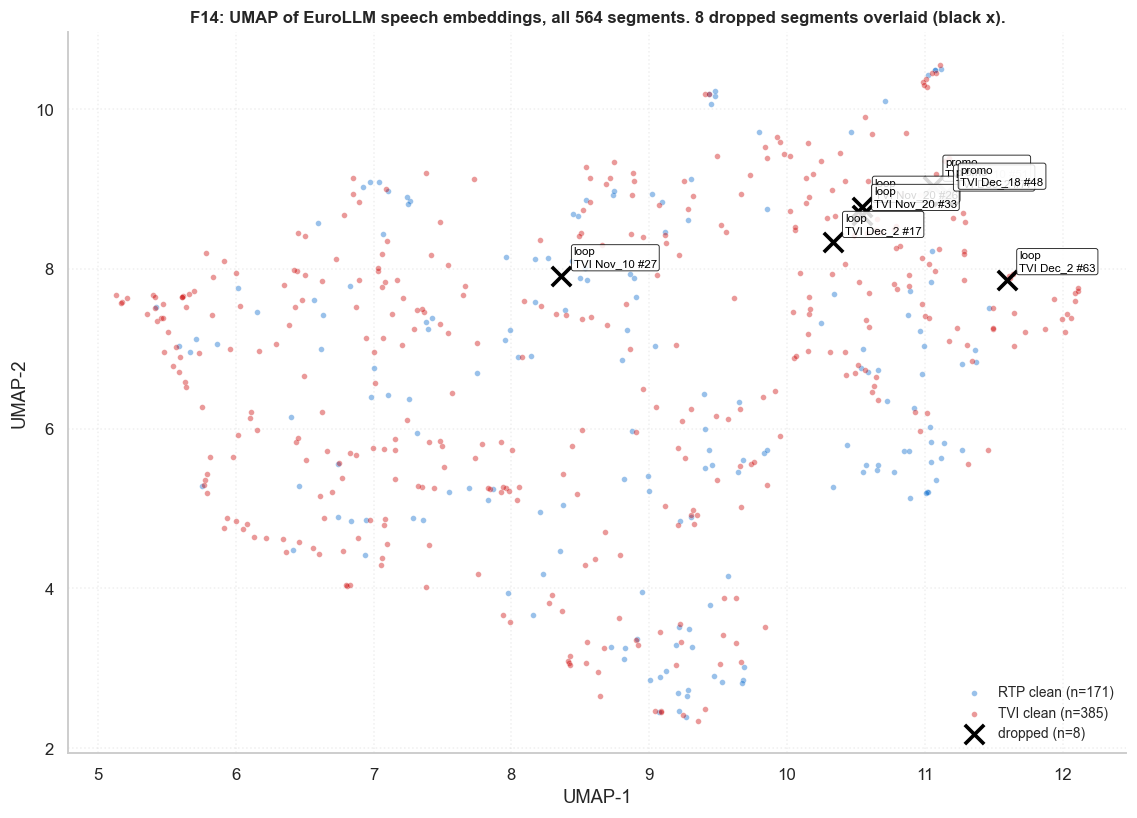

saved: <PROJECT_ROOT>/artifacts/figures/f14_umap_defects.png

Nearest-neighbour distance in 2D (UMAP) space:
  clean -> clean   median = 0.091   p90 = 0.198
  dropped -> clean median = 0.102   p90 = 0.152
  dropped points beyond clean-NN p95: 0 / 8

  if dropped-NN distances >> clean-NN distances, hallucinations
  occupy distinct regions of embedding space (cleaning is validated
  by the geometry). If they overlap, the heuristics did the work.


In [33]:
# Self-contained: fits a fresh UMAP on every row (clean + dropped) so we can
# see where the dropped segments fall in the same projection.

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

_X = normalize(speech_emb, norm="l2")
_X50 = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(_X)
_reducer_full = umap.UMAP(
    n_neighbors=15, min_dist=0.10,
    metric="cosine", random_state=RANDOM_STATE,
)
emb_2d_full = _reducer_full.fit_transform(_X50)

clean_mask = speech_meta["is_clean"].to_numpy()
n_clean   = int(clean_mask.sum())
n_dropped = int((~clean_mask).sum())

fig, ax = plt.subplots(figsize=(10.5, 7.6))

# Clean segments: faint markers per channel
for ch in ["RTP", "TVI"]:
    m = clean_mask & (speech_meta["channel"] == ch).to_numpy()
    ax.scatter(emb_2d_full[m, 0], emb_2d_full[m, 1],
               s=14, alpha=0.40,
               color=CHANNEL_COLORS[ch], edgecolor="white", linewidth=0.3,
               label=f"{ch} clean (n={int(m.sum())})")

# Dropped segments: black crosses, labelled with the manual verdict
m_bad = ~clean_mask
ax.scatter(emb_2d_full[m_bad, 0], emb_2d_full[m_bad, 1],
           s=160, marker="x", linewidth=2.4, color="black",
           label=f"dropped (n={n_dropped})")

# Annotate each dropped point with its verdict (whisper_loop / off_topic_promo)
for i in np.where(m_bad)[0]:
    r = speech_meta.iloc[i]
    verdict = (r.get("manual_verdict") or "").strip() or "auto"
    short = {
        "whisper_loop": "loop",
        "off_topic_promo": "promo",
        "legit_rhetoric": "rhetoric",
    }.get(verdict, verdict)
    ax.annotate(
        f"{short}\n{r['channel']} {r['date_raw']} #{r['segment_idx']}",
        (emb_2d_full[i, 0], emb_2d_full[i, 1]),
        xytext=(8, 6), textcoords="offset points",
        fontsize=7.5, color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black",
                  lw=0.6, alpha=0.85),
    )

ax.set_title("F14: UMAP of EuroLLM speech embeddings, all 564 segments. "
             f"{n_dropped} dropped segments overlaid (black x).",
             fontsize=11)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.grid(linestyle=":", alpha=0.3)
fig.tight_layout()
_p = save_fig(fig, "f14_umap_defects")
plt.show()
print(f"saved: {_p}")

# For each dropped segment, distance to the nearest CLEAN segment in 2D.
# Compare against the clean-to-clean nearest-neighbour distribution.
from scipy.spatial import cKDTree

clean_xy = emb_2d_full[clean_mask]
tree = cKDTree(clean_xy)

# nearest-neighbour distance among clean segments (k=2 to skip self)
clean_nn, _ = tree.query(clean_xy, k=2)
clean_nn_d = clean_nn[:, 1]

# nearest CLEAN segment for each dropped segment
if m_bad.any():
    bad_xy = emb_2d_full[m_bad]
    bad_nn_d, bad_nn_i = tree.query(bad_xy, k=1)
else:
    bad_nn_d = np.array([])

print(f"\nNearest-neighbour distance in 2D (UMAP) space:")
print(f"  clean -> clean   median = {np.median(clean_nn_d):.3f}   "
      f"p90 = {np.quantile(clean_nn_d, 0.9):.3f}")
if bad_nn_d.size:
    print(f"  dropped -> clean median = {np.median(bad_nn_d):.3f}   "
          f"p90 = {np.quantile(bad_nn_d, 0.9):.3f}")
    far = (bad_nn_d > np.quantile(clean_nn_d, 0.95)).sum()
    print(f"  dropped points beyond clean-NN p95: {far} / {n_dropped}")
    print("\n  if dropped-NN distances >> clean-NN distances, hallucinations")
    print("  occupy distinct regions of embedding space (cleaning is validated")
    print("  by the geometry). If they overlap, the heuristics did the work.")